<a href="https://colab.research.google.com/github/luciazhng-web/GeoLife_Trajectory_Mode_Detection/blob/main/3_FeatureExtraction%26Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This section will include:
1. Outlier Idetification;
2. Velocity feature extraction;
3. Mode lable clean
4. Acceleration feature extraction;
5. Heading feature extraction;
6. Global feature extraction;
7. Resmapling and GIS feature extraction(optional)

In [ ]:
!pip install contextily

In [ ]:
!pip install osmnx

In [ ]:
import pandas as pd
import numpy as np
import ast
import os
import matplotlib.pyplot as plt
from os import preadv
#from tqdm import tqdm
import seaborn as sns
from scipy.stats import mode
from pyproj import CRS, Transformer, Proj
#from google.colab import drive
import geopandas as gpd
import contextily as ctx
import osmnx
import shapely


# Mount Google Drive
#drive.mount('/content/drive')
#DATA_ROOT_DIR = '/content/drive/MyDrive/its_geolife/'
#df = pd.read_csv("/content/drive/MyDrive/its_geolife/df_smooth.csv",parse_dates=["datetime"],na_values=["NaN"])

In [ ]:
# projection
crs_wgs84 = CRS.from_epsg(4326)
crs_utm = CRS.from_epsg(32650) # only applies for Beijing
crs_web = CRS.from_epsg(3857)

## Some EDA

In [ ]:
df.describe()

,user_id,lat,lon,dt_sec,x,y,heading,distance,alt_m,speed,...,dt_heading,x_smooth,y_smooth,vx_smooth,vy_smooth,alt_m_smooth,vz_smooth,speed_smooth,distance_smooth,heading_smooth
count,5.953522e+06,5.953522e+06,5.953522e+06,5.951282e+06,5.953522e+06,5.953522e+06,5.951282e+06,5.951282e+06,5.953522e+06,5.951282e+06,...,5.949041e+06,5.951985e+06,5.951985e+06,5.952563e+06,5.952563e+06,5.953522e+06,5.952563e+06,5.952563e+06,5.953522e+06,5.953522e+06
mean,1.973308e+01,4.003439e+01,1.104501e+02,3.383287e+01,1.229525e+07,4.878716e+06,4.629069e+00,8.775238e+01,1.966364e+02,1.551693e+01,...,5.469828e+01,1.229512e+07,4.878739e+06,1.815443e+00,2.717670e-01,1.966665e+02,-1.079391e-02,1.205346e+01,3.811436e+01,-4.604045e-01
std,8.230466e+00,2.658640e+00,3.200715e+01,2.866292e+03,3.563020e+06,3.962565e+05,1.021017e+02,3.155609e+04,1.142764e+03,3.753341e+03,...,8.582661e+01,3.563338e+06,3.962517e+05,1.563940e+03,1.719437e+02,1.142902e+03,2.383664e+00,1.573319e+03,1.305015e+04,8.555279e+01
min,6.000000e+00,-2.138479e+01,-1.799696e+02,1.000000e+00,-2.003412e+07,-2.437820e+06,-1.799938e+02,0.000000e+00,-9.983998e+03,0.000000e+00,...,0.000000e+00,-2.003413e+07,-2.437820e+06,-1.892914e+06,-6.675223e+04,-9.986671e+03,-9.387412e+02,0.000000e+00,0.000000e+00,-1.800000e+02
25%,1.200000e+01,3.993951e+01,1.163196e+02,2.000000e+00,1.294864e+07,4.857156e+06,-8.484879e+01,1.287424e+00,2.999232e+01,5.490184e-01,...,3.091475e+00,1.294864e+07,4.857154e+06,-3.618250e-01,-4.999482e-01,2.987040e+01,-9.221488e-03,0.000000e+00,0.000000e+00,-5.827338e+01
50%,2.100000e+01,3.998057e+01,1.163376e+02,2.000000e+00,1.295064e+07,4.863119e+06,0.000000e+00,4.627352e+00,4.599432e+01,1.975646e+00,...,1.536585e+01,1.295064e+07,4.863119e+06,0.000000e+00,0.000000e+00,4.592276e+01,0.000000e+00,1.612345e+00,3.443719e+00,0.000000e+00
75%,2.700000e+01,4.000777e+01,1.164190e+02,2.000000e+00,1.295971e+07,4.867071e+06,9.220315e+01,1.678291e+01,6.675120e+01,7.486300e+00,...,6.060615e+01,1.295971e+07,4.867071e+06,3.389044e-01,4.832539e-01,6.675169e+01,9.357401e-03,6.909772e+00,1.511385e+01,5.049185e+01
max,3.200000e+01,6.171240e+01,1.799969e+02,2.935507e+06,2.003717e+07,8.791268e+06,1.800000e+02,4.007129e+07,9.999900e+04,6.444994e+06,...,3.599447e+02,2.343005e+07,8.791272e+06,2.516502e+06,1.917183e+05,9.999900e+04,6.669309e+02,2.516502e+06,2.516502e+07,1.800000e+02


Compare the basic features before and after Kalman filter

In [ ]:
df_compare = df.groupby('modes').agg(
    speed_raw_mean=('speed', 'mean'),
    speed_smooth_mean=('speed_smooth', 'mean'),
    speed_raw_std=('speed', 'std'),
    speed_smooth_std=('speed_smooth', 'std'),
    dt_heading_raw_mean=('heading', lambda x: np.mean(np.abs(x.diff()))),
    dt_heading_smooth_mean=('heading_smooth', lambda x: np.mean(np.abs(x.diff()))),
    dt_heading_raw_std=('heading', lambda x: np.std(np.abs(x.diff()))),
    dt_heading_smooth_std=('heading_smooth', lambda x: np.std(np.abs(x.diff()))),
    distance_raw_mean=('distance', 'mean'),
    distance_smooth_mean=('distance_smooth', 'mean'),
    distance_raw_std=('distance', 'std'),
    distance_smooth_std=('distance_smooth', 'std'),
    alt_m_raw_mean=('alt_m', 'mean'),
    alt_m_smooth_mean=('alt_m_smooth', 'mean'),
    alt_m_raw_std=('alt_m', 'std'),
    alt_m_smooth_std=('alt_m_smooth', 'std'),
    count=('modes', 'size')
    ).sort_values(by='count', ascending=False)
df_compare

,speed_raw_mean,speed_smooth_mean,speed_raw_std,speed_smooth_std,dt_heading_raw_mean,dt_heading_smooth_mean,dt_heading_raw_std,dt_heading_smooth_std,distance_raw_mean,distance_smooth_mean,distance_raw_std,distance_smooth_std,alt_m_raw_mean,alt_m_smooth_mean,alt_m_raw_std,alt_m_smooth_std,count
modes,,,,,,,,,,,,,,,,,
walk,1.941720,1.284208,20.104790,8.155340,57.342297,21.754475,85.367050,52.062593,11.275474,3.278239,2109.911024,47.066824,98.367821,98.306221,235.039645,235.134893,1113120
bus,7.097926,6.520430,42.631735,51.550839,41.107259,13.957756,82.444163,45.863637,33.723855,17.528257,3973.673936,1178.404029,55.240772,55.255799,156.738775,157.554835,783631
bike,4.208536,3.633506,44.869750,3.025628,34.008266,10.421727,69.836154,38.195580,33.218390,8.517113,10373.262664,15.864043,48.434900,48.341744,92.696337,92.627224,490179
car,18.049348,11.927211,3966.767414,24.191876,27.310542,12.510705,72.478298,44.823451,94.625728,51.119313,20232.478688,132.850151,105.857675,105.946953,250.225789,250.780257,487918
subway,14.071795,13.560755,15.915608,11.141059,29.482040,12.281335,73.790291,44.199064,46.497466,29.374624,415.359970,57.767026,47.614075,47.581791,74.889846,75.325652,187186
train,26.491682,26.097305,25.835387,18.296089,11.916789,3.422812,47.915688,23.339160,80.836502,61.306858,2249.346542,104.334501,143.971627,143.895345,203.421692,203.421437,130430
taxi,11.733192,11.111796,10.793548,9.361134,35.998227,11.482609,85.271321,44.221977,44.933776,25.224562,4029.585754,64.123902,45.333402,45.326354,45.027187,45.184302,109540
airplane,938.270336,1022.891612,51845.306402,37659.341809,8.067652,5.689471,38.676882,28.175950,9842.365485,10227.879259,518832.549506,376530.514131,7886.767956,7886.756103,4049.363401,4049.476083,5979
boat,7.302672,6.889315,9.296665,9.377925,28.414669,24.659242,66.221975,53.527058,41.594683,40.249334,57.332182,57.525514,15.755385,15.747801,32.936242,32.940784,3602


In [ ]:
columns = ['datetime','trip_id','modes','lon','lat','alt_m','dt_sec','distance','heading','speed','dist_2pts','is_stop','to_remove','orientation_drop','seg_id','seg_id_time_split','speed_smooth','distance_smooth','heading_smooth']
df_abnormal = df[(df['speed_smooth']>500)&(~df['to_remove'])]
df_abnormal[columns]

,datetime,trip_id,modes,lon,lat,alt_m,dt_sec,distance,heading,speed,dist_2pts,is_stop,to_remove,orientation_drop,seg_id,seg_id_time_split,speed_smooth,distance_smooth,heading_smooth
490900,2009-09-12 20:22:48,006_00966,bus,116.455638,39.902911,0.00000,2.0,28.351496,16.655952,14.175748,84.001445,False,False,False,56289,56289_1,15431.570250,30863.140501,62.375458
490901,2009-09-12 20:22:52,006_00966,bus,116.455679,39.903391,0.00000,4.0,69.802970,86.251015,17.450743,152.119326,False,False,False,56289,56289_1,7968.629685,31874.518741,62.398357
490902,2009-09-12 20:22:54,006_00966,bus,116.456031,39.903915,0.00000,2.0,85.541579,62.737038,42.770790,506.771636,False,False,False,56289,56289_1,5043.067696,10086.135392,62.417932
490903,2009-09-12 20:22:58,006_00966,bus,116.455215,39.906865,0.00000,4.0,437.624564,101.979849,109.406141,474.679973,False,False,False,56289,56289_1,2694.257282,10777.029128,62.744427
490904,2009-09-12 20:23:00,006_00966,bus,116.455366,39.907146,0.00000,2.0,44.107263,67.598213,22.053632,51.848616,False,False,False,56289,56289_1,1622.785084,3245.570168,63.121073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4926075,2008-08-13 07:11:41,030_00104,bus,117.048272,40.082250,303.00168,10.0,4288.107264,9.201884,428.810726,8601.921275,False,False,False,542714,542714_1,796.953108,7969.531079,-19.477366
4926373,2008-08-13 17:00:50,030_00105,bus,116.223945,39.891837,95.00616,3.0,7.660888,-165.410885,2.553629,14.229630,False,False,False,542729,542729_1,500.510144,1501.530432,-76.145024
5198593,2008-06-07 09:27:32,031_00427,train,117.047571,39.968779,122.52960,7.0,10831.625776,4.109317,1547.375111,10885.842306,False,False,False,563577,563577_2,502.775913,3519.431391,4.109317
5348459,2008-07-09 20:12:15,<NA>,NaN,116.326391,39.992333,92.04960,1.0,293.789311,-47.470158,293.789311,284.302722,False,False,False,578640,578640_0,623.997176,623.997176,135.857893


In [ ]:
df_seg_test = df[df['seg_id']== 500863] # 59953; 417095;	419675 - US; 492876 - Russia; 500863 - Netherland(speed >500)
df_seg_test[columns]

,datetime,trip_id,modes,lon,lat,alt_m,dt_sec,distance,heading,speed,dist_2pts,is_stop,to_remove,orientation_drop,seg_id,seg_id_time_split,speed_smooth,distance_smooth,heading_smooth
4426420,2009-05-07 19:59:45,<NA>,NaN,4.499135,50.910298,78.3336,5.0,6.202720,58.636914,1.240544,16.949273,False,False,False,500863,500863_0,0.000000,0.000000,0.000000
4426421,2009-05-07 19:59:50,<NA>,NaN,4.499203,50.910342,78.3336,5.0,10.846377,45.740950,2.169275,26.596089,False,False,False,500863,500863_0,0.422200,2.111001,45.740950
4426422,2009-05-07 19:59:55,<NA>,NaN,4.499293,50.910411,78.3336,5.0,15.772486,50.564847,3.154497,35.166026,False,False,False,500863,500863_0,2.330595,11.652977,50.169506
4426423,2009-05-07 20:00:00,<NA>,NaN,4.499389,50.910503,78.3336,5.0,19.442756,56.657135,3.888551,39.892281,False,False,False,500863,500863_0,3.221204,16.106022,53.757796
4426424,2009-05-07 20:00:04,<NA>,NaN,4.499501,50.910595,78.0288,4.0,20.475900,52.489965,5.118975,38.529394,False,False,False,500863,500863_0,3.835017,15.340070,53.665968
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4460218,2009-05-08 05:27:40,<NA>,NaN,116.591615,40.077068,27.7368,4.0,14.979804,-123.361289,3.744951,28.032877,False,False,False,500863,500863_0,4.478602,17.914410,-139.647243
4460219,2009-05-08 05:27:44,<NA>,NaN,116.591543,40.076997,30.1752,4.0,13.074112,-127.809915,3.268528,27.536774,False,False,False,500863,500863_0,4.418857,17.675427,-133.081916
4460220,2009-05-08 05:27:49,<NA>,NaN,116.591456,40.076923,29.5656,5.0,14.480811,-131.974672,2.896162,20.816300,False,False,False,500863,500863_0,4.081267,20.406334,-128.661721
4460221,2009-05-08 05:27:54,<NA>,NaN,116.591425,40.076886,31.6992,5.0,6.394009,-122.663834,1.278802,11.387700,False,False,False,500863,500863_0,3.283354,16.416771,-125.143672


In [ ]:
gdf_after=gpd.GeoDataFrame(
    df_seg_test.assign(geometry=\
                        df_seg_test[['x_smooth','y_smooth']]\
                            .apply(tuple, axis=1)\
                            .apply(shapely.geometry.Point)
                   ),
    crs=crs_web)

In [ ]:
gdf_before=gpd.GeoDataFrame(
    df_seg_test.assign(geometry=\
                        df_seg_test[['x','y']]\
                            .apply(tuple, axis=1)\
                            .apply(shapely.geometry.Point)
                   ),
    crs=crs_web)

No handles with labels found to put in legend.


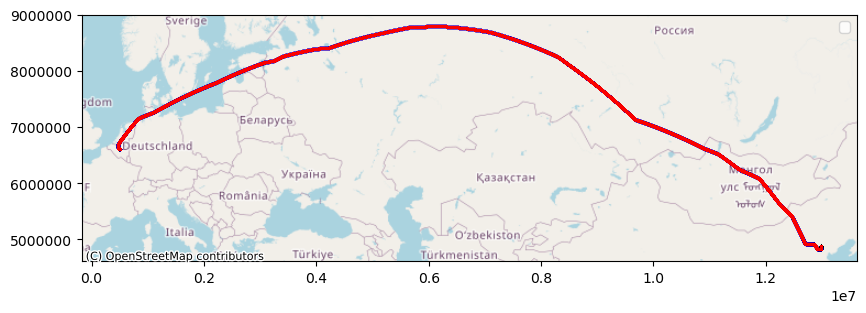

In [ ]:
# Visualize before and after S-G filter (the mode is bike)
fig, ax = plt.subplots(figsize=(10,10))
gdf_before.plot(ax=ax,color='blue',markersize=1.5)
gdf_after.plot(ax=ax,color='red',markersize=1.5,alpha=0.2)
# Add Basemap
ctx.add_basemap(ax,crs=crs_web,source=ctx.providers.OpenStreetMap.Mapnik)
ax.legend()
plt.show()

In [ ]:
df_seg_test = df[df['trip_id']=='006_00251']

In [ ]:
gdf_before=gpd.GeoDataFrame(
    df_seg_test.assign(geometry=\
                        df_seg_test[['x','y']]\
                            .apply(tuple, axis=1)\
                            .apply(shapely.geometry.Point)
                   ),
    crs=crs_web)

In [ ]:
gdf_after=gpd.GeoDataFrame(
    df_seg_test.assign(geometry=\
                        df_seg_test[['x_smooth','y_smooth']]\
                            .apply(tuple, axis=1)\
                            .apply(shapely.geometry.Point)
                   ),
    crs=crs_web)

/tmp/ipython-input-2940941817.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


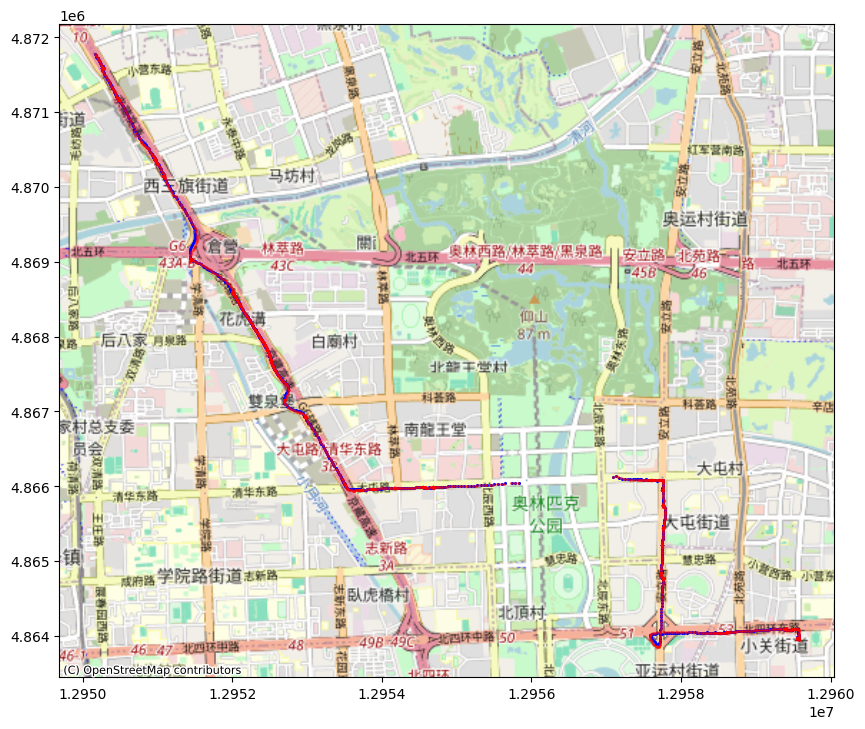

In [ ]:
# Visualize before and after S-G filter (the mode is bike)
fig, ax = plt.subplots(figsize=(10,10))
gdf_before.plot(ax=ax,color='blue',markersize=1.5)
gdf_after.plot(ax=ax,color='red',markersize=1.5,alpha=0.5)
# Add Basemap
ctx.add_basemap(ax,crs=crs_web,source=ctx.providers.OpenStreetMap.Mapnik)
ax.legend()
plt.show()

Check the extreme outliers

In [ ]:
df[(df['speed'] >500)&(df['alt_m'] < 3000)&(~df['orientation_drop'])][columns]

,datetime,trip_id,modes,lon,lat,alt_m,dt_sec,distance,heading,speed,dist_2pts,is_stop,to_remove,orientation_drop,seg_id,seg_id_time_split,speed_smooth,distance_smooth,heading_smooth
15252,2008-12-04 07:55:56,<NA>,NaN,116.409213,39.994345,0.0000,2.0,1525.166710,139.673042,762.583355,362.458358,False,False,False,2097,2097_0,54.772798,109.545597,142.628603
15296,2008-12-04 07:57:26,<NA>,NaN,116.410021,39.991717,0.0000,2.0,1240.440702,139.284683,620.220351,573.751160,False,False,False,2097,2097_0,28.369892,56.739784,144.435439
15349,2008-12-04 07:59:12,<NA>,NaN,116.426120,39.978537,0.0000,2.0,1352.522260,-41.690003,676.261130,1071.721155,False,False,False,2097,2097_0,7.146743,14.293486,168.053412
15355,2008-12-04 07:59:24,<NA>,NaN,116.409591,39.989179,0.0000,2.0,1402.045901,139.275277,701.022950,1510.105298,False,False,False,2097,2097_0,78.985796,157.971593,141.711403
15367,2008-12-04 07:59:48,<NA>,NaN,116.419209,39.981888,0.0000,2.0,1630.797403,139.537827,815.398702,831.364794,False,False,False,2097,2097_0,34.667860,69.335720,-47.450870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5653488,2008-12-23 20:10:06,<NA>,NaN,116.375528,39.986074,13.1064,1.0,802.611599,2.334253,802.611599,52.378576,False,False,False,605751,605751_0,13.215398,13.215398,1.469616
5653490,2008-12-23 20:10:11,<NA>,NaN,116.375941,39.986063,11.8872,1.0,796.165547,1.934646,796.165547,35.641746,False,False,False,605751,605751_0,13.000764,13.000764,1.718706
5759557,2008-08-23 21:26:25,<NA>,NaN,116.305895,40.088615,148.7424,2.0,1148.417996,74.072723,574.208998,1135.158689,False,True,False,617129,617129_1,21.132646,42.265292,74.072723
5851143,2008-09-12 07:17:15,<NA>,NaN,116.319542,40.008238,77.7240,2.0,1088.255065,-80.983962,544.127532,1075.568264,False,False,False,629080,629080_0,40.423813,80.847625,-80.838025


In [ ]:
df[(df['to_remove'])&(~df['is_stop'])&(~df['orientation_drop'])][columns]

,datetime,trip_id,modes,lon,lat,alt_m,dt_sec,distance,heading,speed,dist_2pts,is_stop,to_remove,orientation_drop,seg_id,seg_id_time_split,speed_smooth,distance_smooth,heading_smooth
601,2008-12-01 08:09:40,006_00255,bike,116.423007,39.970237,0.0000,2.0,2.204255,-98.714227,1.102128,4.248979,False,True,False,25,25_0,0.000000,0.000000,0.000000
602,2008-12-01 08:09:42,006_00255,bike,116.423015,39.970223,0.0000,2.0,2.220009,-66.349924,1.110004,4.147495,False,True,False,25,25_0,0.040852,0.081703,-66.349924
603,2008-12-01 08:09:44,006_00255,bike,116.423025,39.970212,0.0000,2.0,1.947343,-55.134777,0.973672,3.728856,False,True,False,25,25_0,0.328770,0.657540,-56.610113
604,2008-12-01 08:09:46,006_00255,bike,116.423036,39.970203,0.0000,2.0,1.791209,-46.872475,0.895605,5.346317,False,True,False,25,25_0,0.604685,1.209370,-52.007481
605,2008-12-01 08:09:48,006_00255,bike,116.423035,39.970176,0.0000,2.0,3.923434,-91.625870,1.961717,5.204334,False,True,False,25,25_0,0.941645,1.883290,-69.835928
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5953458,2008-11-29 16:13:54,<NA>,NaN,116.319324,40.007198,11.2776,2.0,4.972556,96.426807,2.486278,7.855062,False,True,False,639742,639742_0,0.321290,0.642580,129.186220
5953459,2008-11-29 16:13:56,<NA>,NaN,116.319326,40.007218,11.2776,2.0,2.915167,85.619905,1.457583,2.590626,False,True,False,639742,639742_0,0.754338,1.508675,101.834813
5953498,2008-11-29 16:15:14,<NA>,NaN,116.319430,40.008211,14.0208,2.0,6.460115,-109.111310,3.230058,9.202505,False,True,False,639750,639750_0,0.000000,0.000000,0.000000
5953499,2008-11-29 16:15:16,<NA>,NaN,116.319413,40.008196,13.4112,2.0,2.886830,-130.960575,1.443415,6.876802,False,True,False,639750,639750_0,0.053122,0.106244,-130.960575


In [ ]:
seg_25 = df[df['seg_id']==25][columns]

/tmp/ipython-input-3351966786.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


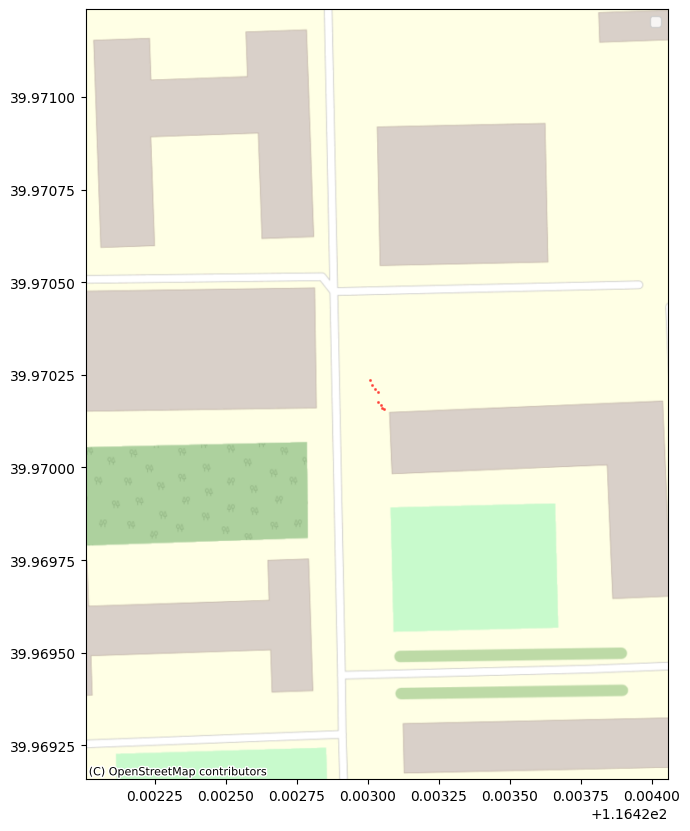

In [ ]:
gdf_seg_25=gpd.GeoDataFrame(
    seg_25.assign(geometry=\
                        seg_25[['lon','lat']]\
                            .apply(tuple, axis=1)\
                            .apply(shapely.geometry.Point)
                   ),
    crs=crs_wgs84)
# Visualize before and after S-G filter (the mode is bike)
fig, ax = plt.subplots(figsize=(10,10))
gdf_seg_25.plot(ax=ax,color='red',markersize=1.5,alpha=0.5)
ax.set_xlim(gdf_seg_25.total_bounds[0] - 0.001, gdf_seg_25.total_bounds[2] + 0.001)
ax.set_ylim(gdf_seg_25.total_bounds[1] - 0.001, gdf_seg_25.total_bounds[3] + 0.001)
# Add Basemap
ctx.add_basemap(ax,crs=crs_wgs84,source=ctx.providers.OpenStreetMap.Mapnik)
ax.legend()
plt.show()

In [ ]:
df[(df['to_remove'])&(~df['is_stop'])&(~df['orientation_drop'])&(df['speed_smooth']>5)][columns]

,datetime,trip_id,modes,lon,lat,alt_m,dt_sec,distance,heading,speed,dist_2pts,is_stop,to_remove,orientation_drop,seg_id,seg_id_time_split,speed_smooth,distance_smooth,heading_smooth
10928,2008-12-03 09:38:47,NaN,NaN,116.419838,39.969378,0.0000,2.0,11.697643,19.588639,5.848821,5.833995,False,True,False,1537,1537_0,5.665112,11.330223,24.291809
16919,2008-12-04 11:28:20,NaN,NaN,116.423801,39.969594,0.0000,2.0,1455.513327,-162.399101,727.756664,1440.912503,False,True,False,2317,2317_1,26.783669,53.567338,-162.399101
16920,2008-12-04 11:28:22,NaN,NaN,116.423774,39.970020,0.0000,2.0,61.950761,92.780875,30.975380,53.688914,False,True,False,2317,2317_1,27.643756,55.287512,179.049688
16921,2008-12-04 11:28:24,NaN,NaN,116.423773,39.969963,0.0000,2.0,8.280196,-90.770311,4.140098,13.670148,False,True,False,2317,2317_1,20.159721,40.319442,173.733606
16922,2008-12-04 11:28:26,NaN,NaN,116.423780,39.969926,0.0000,2.0,5.430572,-81.750112,2.715286,16.693406,False,True,False,2317,2317_1,13.173637,26.347274,173.319650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5916753,2008-10-26 19:42:35,NaN,NaN,116.331483,39.991696,66.7512,2.0,88.166145,122.281825,44.083072,80.369291,False,True,False,635735,635735_0,19.464859,38.929717,-113.340035
5916754,2008-10-26 19:42:37,NaN,NaN,116.331513,39.991647,63.0936,2.0,7.864009,-64.870417,3.932005,4.752059,False,True,False,635735,635735_0,18.686454,37.372908,-116.943422
5916755,2008-10-26 19:42:39,NaN,NaN,116.331500,39.991666,66.4464,2.0,3.116997,117.663515,1.558498,4.282082,False,True,False,635735,635735_0,17.238376,34.476752,-120.049537
5928944,2008-11-06 12:45:40,NaN,NaN,116.322458,40.010037,54.8640,2.0,11.799109,20.929262,5.899555,13.418569,False,True,False,636977,636977_1,5.372141,10.744283,29.006543


In [ ]:
df[df['seg_id']==70395][columns]

,datetime,trip_id,modes,lon,lat,alt_m,dt_sec,distance,heading,speed,dist_2pts,is_stop,to_remove,orientation_drop,seg_id,seg_id_time_split,speed_smooth,distance_smooth,heading_smooth
619217,2009-03-31 03:22:52,NaN,NaN,116.400328,40.053095,29.5656,6.0,30.387647,50.400548,5.064608,199.495633,False,True,False,70395,70395_0,0.000000,0.000000,0.000000
619218,2009-03-31 03:22:54,NaN,NaN,116.400005,40.054301,29.5656,2.0,179.038332,101.585476,89.519166,213.240155,False,True,False,70395,70395_0,3.294579,6.589158,101.585476
619219,2009-03-31 03:22:55,NaN,NaN,116.400035,40.054544,29.2608,1.0,35.497722,84.601696,35.497722,23.664017,False,True,False,70395,70395_0,7.184875,7.184875,93.404114
619220,2009-03-31 03:22:56,NaN,NaN,116.400164,40.054409,28.9560,1.0,24.324684,-53.817751,24.324684,38.686088,False,True,False,70395,70395_0,6.229411,6.229411,72.713822
619221,2009-03-31 03:22:58,NaN,NaN,116.400322,40.054394,28.6512,2.0,17.723249,-7.070285,8.861624,38.212072,False,True,False,70395,70395_0,6.176420,12.352839,28.718936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619274,2009-03-31 03:25:32,NaN,NaN,116.400463,40.052691,61.8744,5.0,5.635748,-133.735774,1.127150,8.807376,False,True,False,70395,70395_0,0.670619,3.353095,119.028672
619275,2009-03-31 03:25:37,NaN,NaN,116.400441,40.052677,61.8744,5.0,3.184822,-140.261372,0.636964,3.449131,True,True,False,70395,70395_0,0.000000,0.000000,0.000000
619276,2009-03-31 03:25:42,NaN,NaN,116.400439,40.052676,61.8744,5.0,0.265928,-146.847115,0.053186,9.197036,True,True,False,70395,70395_0,0.000000,0.000000,0.000000
619277,2009-03-31 03:25:47,NaN,NaN,116.400398,40.052623,59.1312,5.0,8.957711,-120.631610,1.791542,12.320796,False,True,False,70395,70395_0,0.600500,3.002498,-121.478654


In [ ]:
seg_70395 = df[df['seg_id']==70395]

/tmp/ipython-input-3396249469.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


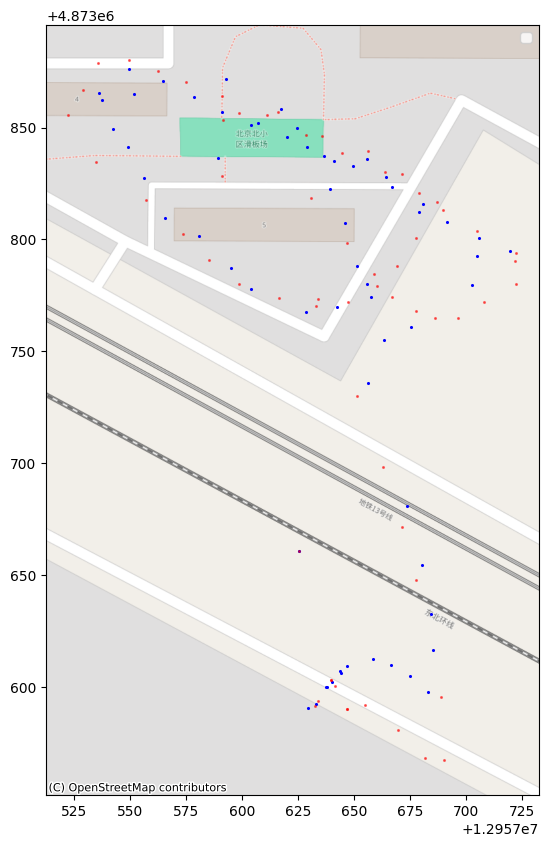

In [ ]:
gdf_seg_70395_before=gpd.GeoDataFrame(
    seg_70395.assign(geometry=\
                        seg_70395[['x','y']]\
                            .apply(tuple, axis=1)\
                            .apply(shapely.geometry.Point)
                   ),
    crs=crs_web)
gdf_seg_70395_after=gpd.GeoDataFrame(
    seg_70395.assign(geometry=\
                        seg_70395[['x_smooth','y_smooth']]\
                            .apply(tuple, axis=1)\
                            .apply(shapely.geometry.Point)
                   ),
    crs=crs_web)
# Visualize before and after S-G filter (the mode is bike)
fig, ax = plt.subplots(figsize=(10,10))
gdf_seg_70395_before.plot(ax=ax,color='blue',markersize=1.5)
gdf_seg_70395_after.plot(ax=ax,color='red',markersize=1.5,alpha=0.5)
# Add Basemap
ctx.add_basemap(ax,crs=crs_web,source=ctx.providers.OpenStreetMap.Mapnik)
ax.legend()
plt.show()

This identified segment is an example of the limitation of existing segmentation logic:


1.   The segmetation is basically based on move and non-move segments;
2.   So within one segment multiple transportation modes may exist;
3.   One of the limitation is that, if the star and end point of one segment is very close, and there is a long time intervals between then, this segment may be identifed as 'a stop segment' incorrectly.

In [ ]:
seg_multi = df[df['seg_id']==234577]

In [ ]:
df[df['seg_id']==234577][columns]

,datetime,trip_id,modes,lon,lat,alt_m,dt_sec,distance,heading,speed,dist_2pts,is_stop,to_remove,orientation_drop,seg_id,seg_id_time_split,speed_smooth,distance_smooth,heading_smooth
1898344,2007-12-22 08:33:27,013_00139,bus,116.325350,40.083987,0.0,5.0,4.200117,-13.420439,0.840023,530.573137,False,True,False,234577,234577_0,0.000000,0.000000,0.000000
1898345,2007-12-22 08:38:50,013_00139,bus,116.320578,40.083577,0.0,323.0,534.522336,-173.592373,1.654868,533.826164,False,True,False,234577,234577_1,0.000000,0.000000,0.000000
1898346,2007-12-22 08:38:53,013_00139,bus,116.320580,40.083610,0.0,3.0,4.848275,87.894650,1.616092,5.464144,False,True,False,234577,234577_1,0.128250,0.384750,87.894650
1898347,2007-12-22 08:38:58,013_00139,bus,116.320533,40.083592,0.0,5.0,5.830893,-152.830047,1.166179,27.433499,False,True,False,234577,234577_1,0.792491,3.962457,-157.069472
1898348,2007-12-22 08:39:03,013_00139,bus,116.320337,40.083580,0.0,5.0,21.962615,-175.554609,4.392523,35.253789,False,True,False,234577,234577_1,2.502497,12.512487,-171.636011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1898459,2007-12-22 23:09:27,NaN,NaN,116.208675,39.932827,0.0,39.0,5392.389361,57.301822,138.266394,6608.818442,False,True,False,234577,234577_12,0.000000,0.000000,0.000000
1898460,2007-12-22 23:09:37,NaN,NaN,116.214177,39.940073,0.0,10.0,1217.369531,59.795356,121.736953,2493.185538,False,True,False,234577,234577_12,61.631534,616.315336,59.795356
1898461,2007-12-22 23:09:47,NaN,NaN,116.220022,39.947632,0.0,10.0,1275.835950,59.336897,127.583595,24532.475611,False,True,False,234577,234577_12,121.468436,1214.684359,59.376720
1898462,2007-12-22 23:20:36,NaN,NaN,116.325908,40.085560,0.0,649.0,23256.647781,59.546845,35.834588,23258.391551,False,True,False,234577,234577_13,0.000000,0.000000,0.000000


In [ ]:
df[df['seg_id']==234577]['modes'].unique()

array(['bus', 'walk', 'subway', nan], dtype=object)

/tmp/ipython-input-473985124.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


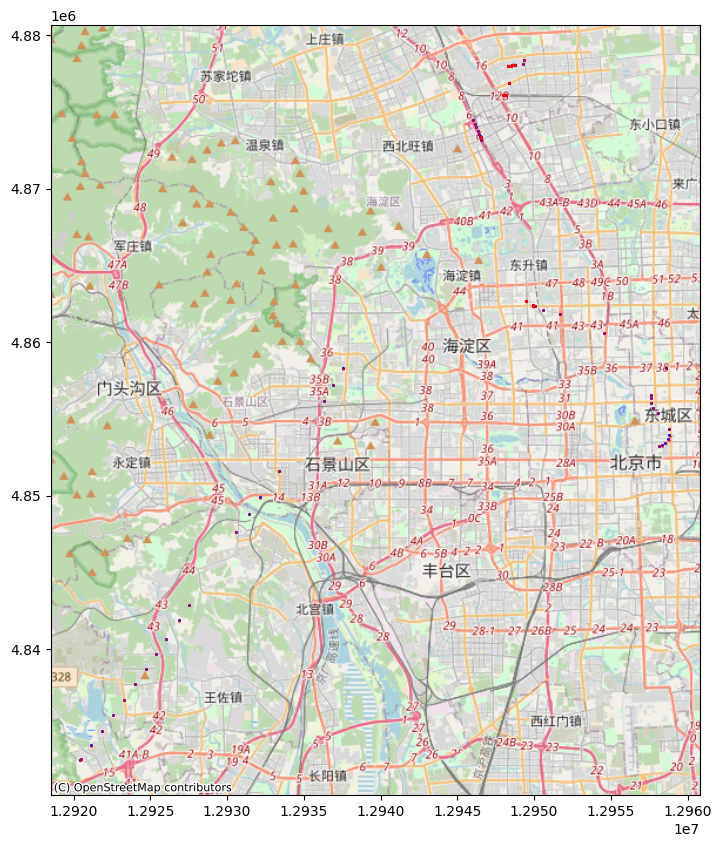

In [ ]:
gdf_seg_multi_before=gpd.GeoDataFrame(
    seg_multi.assign(geometry=\
                        seg_multi[['x','y']]\
                            .apply(tuple, axis=1)\
                            .apply(shapely.geometry.Point)
                   ),
    crs=crs_web)
gdf_seg_multi_after=gpd.GeoDataFrame(
    seg_multi.assign(geometry=\
                        seg_multi[['x_smooth','y_smooth']]\
                            .apply(tuple, axis=1)\
                            .apply(shapely.geometry.Point)
                   ),
    crs=crs_web)
# Visualize before and after S-G filter (the mode is bike)
fig, ax = plt.subplots(figsize=(10,10))
gdf_seg_multi_before.plot(ax=ax,color='blue',markersize=1.5)
gdf_seg_multi_after.plot(ax=ax,color='red',markersize=1.5,alpha=0.5)
# Add Basemap
ctx.add_basemap(ax,crs=crs_web,source=ctx.providers.OpenStreetMap.Mapnik)
ax.legend()
plt.show()

## Outlier identification

Some basic features: acceleration, vertical acceleration

In [ ]:
def cal_acceleration(df):
  df = df.sort_values(by=['user_id', 'file_name', 'datetime']).reset_index(drop=True)
   # calculate acceleration
  # Shift coordinates to calculate distance between current and previous point
  df['vel_prev'] = df['speed_smooth'].shift(1)

  # Apply VECTORIZED Haversine calculation to the shifted columns
  # This is much faster than .apply()
  df['accel'] = (df['speed_smooth'] - df['vel_prev'])/df['dt_sec']

  # Drop temporary columns
  df = df.drop(columns=['vel_prev'])
  print(df['accel'].describe())

  return df

In [ ]:
df = cal_acceleration(df)

count    5.950219e+06
mean     2.288301e-01
std      4.154249e+02
min     -1.104937e+05
25%     -2.132315e-02
50%      0.000000e+00
75%      6.120892e-02
max      9.464568e+05
Name: accel, dtype: float64


In [ ]:
def cal_vertical_speed(df):

  df = df.sort_values(by=['user_id', 'file_name', 'datetime']).reset_index(drop=True)

  # Shift coordinates to calculate distance between current and previous point
  df['alt_prev'] = df.groupby(['user_id', 'file_name'])['alt_m_smooth'].shift(1)

  # Apply VECTORIZED Haversine calculation to the shifted columns
  # This is much faster than .apply()
  df['alt_dif'] = df['alt_m_smooth'] - df['alt_prev']
  df['ver_speed'] = df['alt_dif']/df['dt_sec']

  # Drop temporary columns
  df = df.drop(columns=['alt_prev','alt_dif'])
  print(df['ver_speed'].describe())

  return df

In [ ]:
df = cal_vertical_speed(df)

count    5.951282e+06
mean    -1.960705e-02
std      5.003314e+00
min     -4.153642e+03
25%     -4.655082e-02
50%      0.000000e+00
75%      5.115482e-02
max      1.839701e+03
Name: ver_speed, dtype: float64


In [ ]:
# filter abnormal altitude value
MIN_PLAUSIBLE_ALT_M = -200
MAX_PLAUSIBLE_ALT_M = 13500

df['alt_outlier'] = False

Max_alt_outlier_mask = (df['alt_m_smooth'].abs() > MAX_PLAUSIBLE_ALT_M)
Min_alt_outlier_mask = (df['alt_m_smooth'] < MIN_PLAUSIBLE_ALT_M)
alt_outlier_mask = Max_alt_outlier_mask|Min_alt_outlier_mask

df.loc[alt_outlier_mask, ['alt_outlier']] = True
print(f"Filtered {alt_outlier_mask.sum()} points due to extreme altitude value between {MIN_PLAUSIBLE_ALT_M} M and {MAX_PLAUSIBLE_ALT_M} M).")

Filtered 4116 points due to extreme altitude value between -200 M and 13500 M).


In [ ]:
df.head(10)

,user_id,lat,lon,datetime,file_name,modes,trip_id,dt_sec,x,y,...,vx_smooth,vy_smooth,alt_m_smooth,vz_smooth,speed_smooth,distance_smooth,heading_smooth,accel,ver_speed,alt_outlier
0,6,39.993189,116.420565,2008-12-01 07:49:36,1-7.plt,NaN,<NA>,NaN,1.295988e+07,4.864953e+06,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,NaN,NaN,False
1,6,39.995136,116.417182,2008-12-01 07:49:38,1-7.plt,NaN,<NA>,2.0,1.295950e+07,4.865235e+06,...,-6.929902,5.205950,0.0,0.0,8.667494,17.334988,143.085030,4.333747,0.0,False
2,6,39.997684,116.412568,2008-12-01 07:49:40,1-7.plt,NaN,<NA>,2.0,1.295899e+07,4.865606e+06,...,-82.809912,59.917833,0.0,0.0,102.213640,204.427281,144.112054,46.773073,0.0,False
3,6,39.996701,116.414270,2008-12-01 07:49:42,1-7.plt,NaN,<NA>,2.0,1.295918e+07,4.865463e+06,...,-56.733547,40.106686,0.0,0.0,69.478354,138.956708,144.742337,-16.367643,0.0,False
4,6,39.993076,116.420262,2008-12-01 07:49:44,1-7.plt,NaN,<NA>,2.0,1.295984e+07,4.864936e+06,...,42.803821,-37.167665,0.0,0.0,56.688644,113.377288,-40.968627,-6.394855,0.0,False
5,6,39.993128,116.419989,2008-12-01 07:49:46,1-7.plt,NaN,<NA>,2.0,1.295981e+07,4.864944e+06,...,61.790482,-52.628715,0.0,0.0,81.165543,162.331086,-40.421983,12.238449,0.0,False
6,6,40.002311,116.404073,2008-12-01 07:49:50,1-7.plt,NaN,<NA>,4.0,1.295804e+07,4.866278e+06,...,-73.651301,50.681881,0.0,0.0,89.404515,357.618059,145.466862,2.059743,0.0,False
7,6,40.008903,116.392543,2008-12-01 07:49:52,1-7.plt,NaN,<NA>,2.0,1.295676e+07,4.867236e+06,...,-166.258518,120.822350,0.0,0.0,205.523563,411.047127,143.993580,58.059524,0.0,False
8,6,39.994429,116.417373,2008-12-01 07:49:54,1-7.plt,NaN,<NA>,2.0,1.295952e+07,4.865133e+06,...,-81.440153,56.593945,0.0,0.0,99.173450,198.346900,145.204002,-53.175057,0.0,False
9,6,39.993944,116.418113,2008-12-01 07:49:56,1-7.plt,NaN,<NA>,2.0,1.295961e+07,4.865062e+06,...,-31.039088,18.497648,0.0,0.0,36.132921,72.265842,149.207304,-31.520265,0.0,False


In [ ]:
def filter_outliers(df):

  # Maximum plausible speed (km/h): Fastest recorded passenger train or jet (for extreme outliers)
  # observed maximum speed above 500 for airplane - 1800KPH
  MAX_PLAUSIBLE_SPEED = 550
  # Maximum plausible acceleration (km/h/s): ~2G (about 20 m/s/s)
  MAX_PLAUSIBLE_ACCEL = 20.0
  # Maximum plausible vertical speed (m/s): 45 m/s ≈ 160 km/h
  MAX_PLAUSIBLE_VER_SPEED = 45.0

  # [Function content remains the same]
  print(f"\nApplying noise filtering: Max Speed={MAX_PLAUSIBLE_SPEED} mps, Max Accel={MAX_PLAUSIBLE_ACCEL} m/s/s, Max Vspeed={MAX_PLAUSIBLE_VER_SPEED} mps.")

  df['speed_filtered'] = df['speed_smooth']
  df['accel_filtered'] = df['accel']
  df['vspeed_filtered'] = df['ver_speed']

  speed_outlier_mask = (df['speed_filtered'] > MAX_PLAUSIBLE_SPEED)
  accel_outlier_mask = (df['accel_filtered'].abs() > MAX_PLAUSIBLE_ACCEL)
  vspeed_outlier_mask = (df['vspeed_filtered'].abs() > MAX_PLAUSIBLE_VER_SPEED)

  df.loc[speed_outlier_mask, 'speed_filtered'] = np.nan
  df.loc[accel_outlier_mask, 'accel_filtered'] = np.nan
  df.loc[vspeed_outlier_mask, 'ver_speed'] = np.nan

  print(f"Filtered {speed_outlier_mask.sum()} points due to extreme speed.")
  print(f"Filtered {accel_outlier_mask.sum()} points due to extreme acceleration.")
  print(f"Filtered {vspeed_outlier_mask.sum()} points due to extreme vertical speed.")


  df.loc[df['speed_smooth'].isna(), 'speed_filtered'] = np.nan
  df.loc[df['accel'].isna(), 'accel_filtered'] = np.nan
  df.loc[df['ver_speed'].isna(), 'vspeed_filtered'] = np.nan

  return df

In [ ]:
df = filter_outliers(df)


Applying noise filtering: Max Speed=550 mps, Max Accel=20.0 m/s/s, Max Vspeed=45.0 mps.
Filtered 350 points due to extreme speed.
Filtered 1487 points due to extreme acceleration.
Filtered 0 points due to extreme vertical speed.


Continue to check speed outliers - if the altitude is lower than 5000meter, the speed should be lower than 150m/s (but this outlier will not apply to airplane mode)

In [ ]:
df['speed_outlier'] = False
mask_speed_outlier = ((df['speed_smooth']>150) & (df['alt_m_smooth']<5000))
df.loc[mask_speed_outlier, ['speed_outlier']] = True

columns = ['datetime','trip_id','modes','lon','lat','alt_m','dt_sec','distance','heading','speed','dist_2pts','is_stop','to_remove','orientation_drop','seg_id','seg_id_time_split','speed_smooth','distance_smooth','heading_smooth','speed_filtered']
df[df['speed_outlier']][columns]

,datetime,trip_id,modes,lon,lat,alt_m,dt_sec,distance,heading,speed,dist_2pts,is_stop,to_remove,orientation_drop,seg_id,seg_id_time_split,speed_smooth,distance_smooth,heading_smooth,speed_filtered
7,2008-12-01 07:49:52,<NA>,NaN,116.392543,40.008903,0.0000,2.0,1.601621e+03,143.262469,800.810673,1.871866e+03,False,True,True,1,1_0,205.523563,4.110471e+02,143.993580,205.523563
11601,2008-12-03 10:03:23,<NA>,NaN,116.414625,39.967540,0.0000,2.0,4.518571e+02,23.831956,225.928557,6.327342e+02,False,True,True,1683,1683_1,156.453571,3.129071e+02,22.639140,156.453571
11602,2008-12-03 10:03:25,<NA>,NaN,116.416120,39.968028,0.0000,2.0,1.808885e+02,23.069737,90.444275,3.255798e+02,False,False,False,1683,1683_1,153.873257,3.077465e+02,22.911384,153.873257
15319,2008-12-04 07:58:12,<NA>,NaN,116.389320,40.004777,0.0000,2.0,1.035731e+03,139.443907,517.865739,3.538355e+03,False,True,True,2097,2097_0,161.312978,3.226260e+02,139.127239,161.312978
34281,2008-12-06 13:03:21,<NA>,NaN,116.414970,39.997996,0.0000,2.0,1.106992e+02,-40.426200,55.349593,1.478563e+02,False,False,False,5481,5481_1,167.605290,3.352106e+02,-96.198104,167.605290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5720019,2008-05-12 18:53:25,031_00260,bus,116.364842,39.965807,166.1160,2.0,1.568189e+01,-6.381220,7.840944,3.160317e+01,False,False,False,613418,613418_0,153.224350,3.064487e+02,8.978233,153.224350
5948500,2008-11-29 10:48:33,<NA>,NaN,116.418500,39.967531,32.0040,2.0,9.933944e+02,109.855734,496.697196,1.014980e+03,False,True,True,639040,639040_1,153.384560,3.067691e+02,112.171153,153.384560
5948501,2008-11-29 10:48:35,<NA>,NaN,116.418464,39.967679,46.9392,2.0,2.186712e+01,100.560060,10.933559,2.655891e+01,False,False,False,639040,639040_1,163.713124,3.274262e+02,111.227337,163.713124
5949369,2008-11-29 12:02:14,<NA>,NaN,65.656491,49.759795,149.9616,20.0,5.435671e+06,145.726541,271783.574255,5.636163e+06,False,True,True,639156,639156_2,285557.419138,5.711148e+06,145.726845,NaN


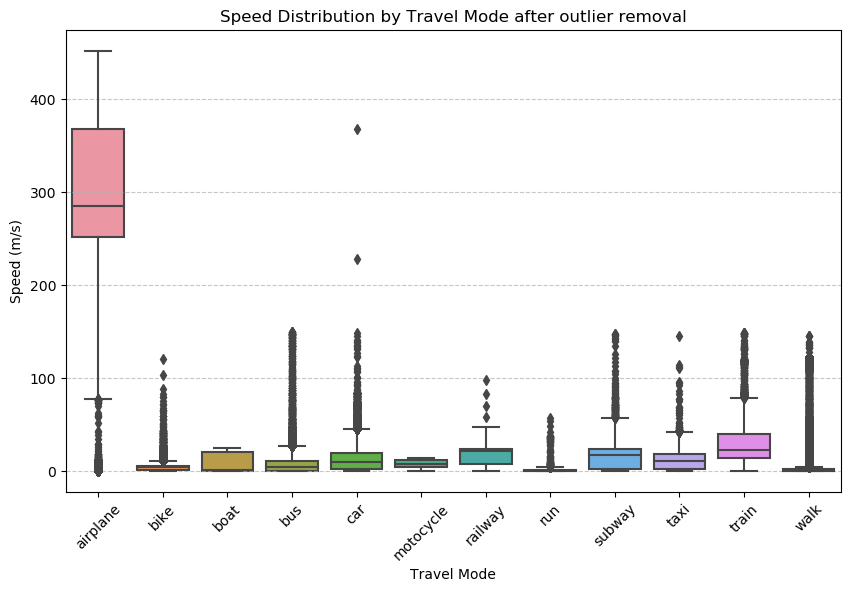

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_clean = df[(~df['speed_outlier'])& (df['accel_filtered'].notna()) & (df['vspeed_filtered'].notna()) & (~df['alt_outlier'])]

plt.figure(figsize=(10, 6))
sns.boxplot(x='modes', y='speed_filtered', data=df_clean)

plt.title("Speed Distribution by Travel Mode after outlier removal")
plt.xlabel("Travel Mode")
plt.ylabel("Speed (m/s)")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

## Velocity features
The trajectory features are calculated using a statistical method. The mean, percentiles (10th, 30th, 50th, 70th, and 95th), standard deviation, skewness, and kurtosis of speed_smooth feature are calculated.



In [ ]:
from scipy.stats import skew, kurtosis
def apply_speed_features(original_df):

  def calculate_speed_features(df):
    # Define the list of percentile values to calculate
    percentiles = [10, 30, 50, 70, 95]

    # Create an aggregation dictionary for all required statistics
    agg_dict = {
      'speed_mean': ('speed_filtered', 'mean'),
      'speed_std': ('speed_filtered', 'std'),
      'speed_skew': ('speed_filtered', lambda x: skew(x.dropna())),
      'speed_kurt': ('speed_filtered', lambda x: kurtosis(x.dropna())),
      }

    # Add percentile calculations to the aggregation dictionary
    for p in percentiles:
      agg_dict[f'speed_p{p}'] = ('speed_filtered', lambda x, p=p: np.nanpercentile(x, p))

    # Perform the grouped aggregation
    feature_df = df.groupby('seg_id_time_split').agg(
      **agg_dict
      ).reset_index()
    return feature_df

  feature_df = calculate_speed_features(original_df)

  merged_df = pd.merge(original_df, feature_df,on='seg_id_time_split',how='left')

  return merged_df

In [ ]:
seg_multi = df[df['seg_id']==639040]
seg_multi[columns]

,datetime,trip_id,modes,lon,lat,alt_m,dt_sec,distance,heading,speed,dist_2pts,is_stop,to_remove,orientation_drop,seg_id,seg_id_time_split,speed_smooth,distance_smooth,heading_smooth,speed_filtered
5948474,2008-11-29 10:46:27,NaN,NaN,116.413873,39.967542,50.2920,2.0,2.312975,-54.722354,1.156488,9.719187,False,False,False,639040,639040_0,0.000000,0.000000,0.000000,0.000000
5948475,2008-11-29 10:46:29,NaN,NaN,116.413930,39.967514,50.2920,2.0,7.536696,-32.657760,3.768348,16.521656,False,False,False,639040,639040_0,0.138687,0.277373,-32.657760,0.138687
5948476,2008-11-29 10:46:31,NaN,NaN,116.414005,39.967490,50.2920,2.0,9.047489,-22.662082,4.523744,20.115573,False,False,False,639040,639040_0,1.474369,2.948738,-23.658763,1.474369
5948477,2008-11-29 10:46:33,NaN,NaN,116.414103,39.967474,50.2920,2.0,11.154097,-12.025748,5.577049,25.279088,False,False,False,639040,639040_0,3.194718,6.389436,-17.380445,3.194718
5948478,2008-11-29 10:46:35,NaN,NaN,116.414231,39.967473,50.2920,2.0,14.249635,-0.584032,7.124818,31.568976,False,False,False,639040,639040_0,4.566637,9.133275,-10.693491,4.566637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5948552,2008-11-29 10:52:19,NaN,NaN,116.433178,39.966031,53.3400,2.0,8.633603,-73.521088,4.316802,14.429443,False,False,False,639040,639040_2,9.299346,18.598691,-43.806862,9.299346
5948553,2008-11-29 10:52:21,NaN,NaN,116.433184,39.965991,53.3400,2.0,5.848067,-83.441848,2.924034,8.442576,False,False,False,639040,639040_2,8.558973,17.117947,-45.893465,8.558973
5948554,2008-11-29 10:52:23,NaN,NaN,116.433173,39.965973,53.3400,2.0,2.886965,-115.097048,1.443483,5.848857,False,False,False,639040,639040_2,7.656145,15.312290,-48.177689,7.656145
5948555,2008-11-29 10:52:25,NaN,NaN,116.433137,39.965973,53.0352,2.0,4.007502,180.000000,2.003751,6.757389,False,False,False,639040,639040_2,6.592357,13.184714,-50.913980,6.592357


In [ ]:
seg_multi = cal_acceleration(seg_multi)

count    82.000000
mean      0.130019
std       8.725881
min     -17.764013
25%      -0.348730
50%      -0.005613
75%       0.283795
max      72.170323
Name: accel, dtype: float64


In [ ]:
seg_multi = cal_vertical_speed(seg_multi)

count    82.000000
mean     -1.646237
std       5.376791
min     -33.496728
25%      -0.554245
50%      -0.146873
75%       0.255792
max       2.692611
Name: ver_speed, dtype: float64


In [ ]:
seg_multi = filter_outliers(seg_multi)


Applying noise filtering: Max Speed=550 mps, Max Accel=20.0 m/s/s, Max Vspeed=45.0 mps.
Filtered 1 points due to extreme horizontal/vertical speed or acceleration.


In [ ]:
df_seg_multi = apply_speed_features(seg_multi)
speed_column = ['datetime','trip_id','modes','lon','lat','dt_sec','speed','dist_2pts','is_stop','to_remove','orientation_drop','seg_id','seg_id_time_split','speed_smooth','speed_outlier','speed_filtered','speed_mean','speed_std','speed_skew']
df_seg_multi[speed_column]

,datetime,trip_id,modes,lon,lat,dt_sec,speed,dist_2pts,is_stop,to_remove,orientation_drop,seg_id,seg_id_time_split,speed_smooth,speed_filtered,speed_mean,speed_std,speed_skew
0,2008-11-29 10:46:27,NaN,NaN,116.413873,39.967542,2.0,1.156488,9.719187,False,False,False,639040,639040_0,0.000000,0.000000,6.229314,2.475351,-1.657150
1,2008-11-29 10:46:29,NaN,NaN,116.413930,39.967514,2.0,3.768348,16.521656,False,False,False,639040,639040_0,0.138687,0.138687,6.229314,2.475351,-1.657150
2,2008-11-29 10:46:31,NaN,NaN,116.414005,39.967490,2.0,4.523744,20.115573,False,False,False,639040,639040_0,1.474369,1.474369,6.229314,2.475351,-1.657150
3,2008-11-29 10:46:33,NaN,NaN,116.414103,39.967474,2.0,5.577049,25.279088,False,False,False,639040,639040_0,3.194718,3.194718,6.229314,2.475351,-1.657150
4,2008-11-29 10:46:35,NaN,NaN,116.414231,39.967473,2.0,7.124818,31.568976,False,False,False,639040,639040_0,4.566637,4.566637,6.229314,2.475351,-1.657150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,2008-11-29 10:52:19,NaN,NaN,116.433178,39.966031,2.0,4.316802,14.429443,False,False,False,639040,639040_2,9.299346,9.299346,9.695692,3.737865,-0.429545
79,2008-11-29 10:52:21,NaN,NaN,116.433184,39.965991,2.0,2.924034,8.442576,False,False,False,639040,639040_2,8.558973,8.558973,9.695692,3.737865,-0.429545
80,2008-11-29 10:52:23,NaN,NaN,116.433173,39.965973,2.0,1.443483,5.848857,False,False,False,639040,639040_2,7.656145,7.656145,9.695692,3.737865,-0.429545
81,2008-11-29 10:52:25,NaN,NaN,116.433137,39.965973,2.0,2.003751,6.757389,False,False,False,639040,639040_2,6.592357,6.592357,9.695692,3.737865,-0.429545


In [ ]:
df_features = apply_speed_features(df)

In [ ]:
speed_column = ['datetime','trip_id','modes','lon','lat','alt_m_smooth','dt_sec','speed','dist_2pts','is_stop','to_remove','orientation_drop','seg_id','seg_id_time_split','speed_smooth','speed_outlier','speed_filtered','speed_mean','speed_std','speed_skew']
df_features[speed_column]

,datetime,trip_id,modes,lon,lat,alt_m_smooth,dt_sec,speed,dist_2pts,is_stop,to_remove,orientation_drop,seg_id,seg_id_time_split,speed_smooth,speed_outlier,speed_filtered,speed_mean,speed_std,speed_skew
0,2008-12-01 07:49:36,<NA>,NaN,116.420565,39.993189,0.000000,NaN,NaN,NaN,False,False,False,1,1_0,0.000000,False,0.000000,27.677472,38.572189,2.580997
1,2008-12-01 07:49:38,<NA>,NaN,116.417182,39.995136,0.000000,2.0,235.510173,1104.133086,False,True,True,1,1_0,8.667494,False,8.667494,27.677472,38.572189,2.580997
2,2008-12-01 07:49:40,<NA>,NaN,116.412568,39.997684,0.000000,2.0,316.582589,395.974249,False,True,True,1,1_0,102.213640,False,102.213640,27.677472,38.572189,2.580997
3,2008-12-01 07:49:42,<NA>,NaN,116.414270,39.996701,0.000000,2.0,118.638983,1087.157662,False,True,True,1,1_0,69.478354,False,69.478354,27.677472,38.572189,2.580997
4,2008-12-01 07:49:44,<NA>,NaN,116.420262,39.993076,0.000000,2.0,424.963144,821.494637,False,True,True,1,1_0,56.688644,False,56.688644,27.677472,38.572189,2.580997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5953517,2008-11-29 16:15:52,<NA>,NaN,116.319362,40.007802,24.589845,2.0,1.889341,6.979578,False,False,False,639756,639756_0,1.274710,False,1.274710,1.040200,0.697482,-0.668049
5953518,2008-11-29 16:15:54,<NA>,NaN,116.319360,40.007780,25.401235,2.0,1.602543,6.685356,False,False,False,639756,639756_0,1.516859,False,1.516859,1.040200,0.697482,-0.668049
5953519,2008-11-29 16:15:56,<NA>,NaN,116.319362,40.007756,26.438467,2.0,1.747555,5.814417,False,False,False,639756,639756_0,1.628715,False,1.628715,1.040200,0.697482,-0.668049
5953520,2008-11-29 16:15:58,<NA>,NaN,116.319361,40.007740,27.742477,2.0,1.164002,5.002412,False,False,False,639756,639756_0,1.603901,False,1.603901,1.040200,0.697482,-0.668049


In [ ]:
df_features[(df_features['speed_smooth']< 550)&df_features['speed_outlier']][speed_column]

,datetime,trip_id,modes,lon,lat,alt_m_smooth,dt_sec,speed,dist_2pts,is_stop,to_remove,orientation_drop,seg_id,seg_id_time_split,speed_smooth,speed_outlier,speed_filtered,speed_mean,speed_std,speed_skew
7,2008-12-01 07:49:52,<NA>,NaN,116.392543,40.008903,0.000000,2.0,800.810673,1871.866283,False,True,True,1,1_0,205.523563,True,205.523563,27.677472,38.572189,2.580997
11601,2008-12-03 10:03:23,<NA>,NaN,116.414625,39.967540,0.000000,2.0,225.928557,632.734233,False,True,True,1683,1683_1,156.453571,True,156.453571,24.623033,32.599582,2.616646
11602,2008-12-03 10:03:25,<NA>,NaN,116.416120,39.968028,0.000000,2.0,90.444275,325.579801,False,False,False,1683,1683_1,153.873257,True,153.873257,24.623033,32.599582,2.616646
15319,2008-12-04 07:58:12,<NA>,NaN,116.389320,40.004777,0.000000,2.0,517.865739,3538.354737,False,True,True,2097,2097_0,161.312978,True,161.312978,36.918532,29.288048,1.434020
34281,2008-12-06 13:03:21,<NA>,NaN,116.414970,39.997996,0.000000,2.0,55.349593,147.856308,False,False,False,5481,5481_1,167.605290,True,167.605290,42.259501,60.876893,1.018142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5720017,2008-05-12 18:53:22,031_00260,bus,116.362861,39.966156,5.794623,27.0,49.846553,1542.229701,False,True,True,613418,613418_0,156.910410,True,156.910410,19.698754,35.201269,2.858465
5720018,2008-05-12 18:53:23,031_00260,bus,116.364702,39.965819,87.759519,1.0,210.703420,226.274878,False,False,False,613418,613418_0,162.393096,True,162.393096,19.698754,35.201269,2.858465
5720019,2008-05-12 18:53:25,031_00260,bus,116.364842,39.965807,124.711624,2.0,7.840944,31.603168,False,False,False,613418,613418_0,153.224350,True,153.224350,19.698754,35.201269,2.858465
5948500,2008-11-29 10:48:33,<NA>,NaN,116.418500,39.967531,142.695440,2.0,496.697196,1014.980495,False,True,True,639040,639040_1,153.384560,True,153.384560,28.983996,42.163275,2.195264


Plotting a few speed features in different modes

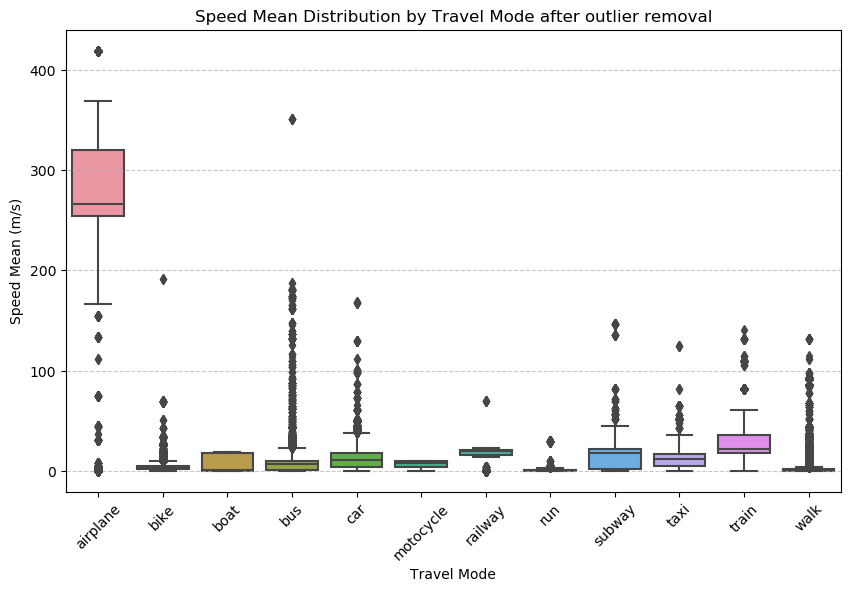

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_clean = df_features[(df_features['speed_filtered'].notna())& (df_features['accel_filtered'].notna()) & (df_features['vspeed_filtered'].notna()) & (~df_features['alt_outlier'])]

plt.figure(figsize=(10, 6))
sns.boxplot(x='modes', y='speed_mean', data=df_clean)

plt.title("Speed Mean Distribution by Travel Mode after outlier removal")
plt.xlabel("Travel Mode")
plt.ylabel("Speed Mean (m/s)")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

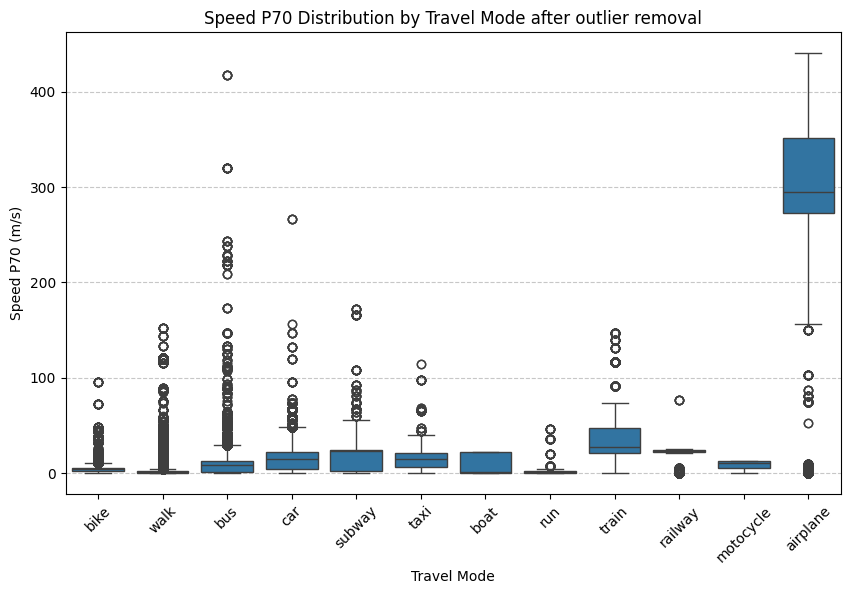

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_clean = df_features[(df_features['speed_filtered'].notna())& (df_features['accel_filtered'].notna()) & (df_features['vspeed_filtered'].notna()) & (~df_features['alt_outlier'])]

plt.figure(figsize=(10, 6))
sns.boxplot(x='modes', y='speed_p70', data=df_clean)

plt.title("Speed P70 Distribution by Travel Mode after outlier removal")
plt.xlabel("Travel Mode")
plt.ylabel("Speed P70 (m/s)")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

## Mode label clean

Based on the speed features profiles for different modes, do combine or remove certain mode lables as below:
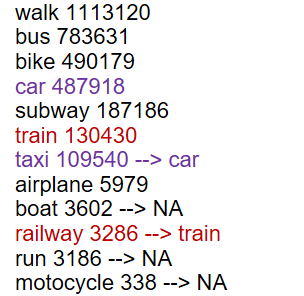

In [ ]:
def clean_mode_labels(feature_df: pd.DataFrame) -> pd.DataFrame:

    # Define Merge Mapping: Consolidate similar or small classes into large ones
    mode_mapping = {
        'taxi': 'car',      # Merge taxi into car
        'railway': 'train'  # Merge railway into train
    }

    # Define Modes to Remove: Classes with very low counts (will be set to NaN)
    modes_to_remove = ['boat', 'run', 'motocycle']

    # Apply merge operation
    feature_df['modes'] = feature_df['modes'].replace(mode_mapping)

    # Apply removal operation (set to NaN)
    feature_df['modes'] = feature_df['modes'].replace(modes_to_remove, np.nan)

    # Show counts, including the NaN values (removed modes)
    print(feature_df['modes'].value_counts(dropna=False))

    return feature_df

In [ ]:
df_features.groupby('user_id')['modes'].unique()

user_id
6     [NaN, 'bike', 'walk', 'bus', 'car', 'subway']
...
10    [NaN, 'walk', 'subway', 'car', 'taxi']
Categor...
11    ['subway', 'walk', 'bus', 'taxi', NaN, 'car', ...
12    ['bus', 'walk', 'taxi', NaN, 'subway', 'bike',...
13    [NaN, 'taxi', 'walk', 'bus', 'train', 'subway'...
14    ['walk', 'bike', NaN, 'subway', 'bus']
Categor...
15    [NaN, 'bus', 'walk', 'bike']
Categories (12, o...
16    [NaN]
Categories (12, object): ['airplane', 'b...
17    [NaN, 'subway', 'walk', 'car']
Categories (12,...
18    [NaN, 'car', 'walk']
Categories (12, object): ...
19    [NaN, 'bike', 'bus', 'walk', 'subway', 'car', ...
20    ['bike', 'walk', 'bus', NaN, 'subway', 'car']
...
21    ['bike', 'walk', NaN, 'bus', 'taxi', 'train', ...
22    [NaN, 'train', 'bike', 'bus', 'car', ..., 'sub...
23    [NaN, 'bike', 'bus', 'walk', 'car']
Categories...
24    [NaN]
Categories (12, object): ['airplane', 'b...
25    ['bike', NaN, 'walk']
Categories (12, object):...
26    ['bus', 'walk', NaN, 'taxi', 'car'

In [ ]:
df_features[(df_features['user_id']==27)].groupby('file_name')['modes'].unique()

file_name
2007-07-25-GPS.plt    ['taxi', NaN, 'walk']
Categories (12, object):...
2007-10-01-GPS.plt    [NaN]
Categories (12, object): ['airplane', 'b...
2007-10-02-GPS.plt    [NaN]
Categories (12, object): ['airplane', 'b...
2007-10-03-GPS.plt    [NaN]
Categories (12, object): ['airplane', 'b...
2007-10-04-GPS.plt    [NaN]
Categories (12, object): ['airplane', 'b...
                                            ...                        
TKLG260707.plt        ['walk', NaN]
Categories (12, object): ['airpl...
TKLG270707.plt        ['walk', 'boat', NaN, 'taxi', 'train']
Categor...
plt-2008-7-20.plt     [NaN, 'taxi', 'walk', 'bus']
Categories (12, o...
plt-2008-7-23.plt     [NaN, 'walk', 'subway']
Categories (12, object...
plt-2008-7-24.plt     ['walk', NaN, 'taxi', 'bus']
Categories (12, o...
Name: modes, Length: 238, dtype: object

In [ ]:
# test samples - one trajectory file
seg_multi = df_features[(df_features['user_id']==27)&(df_features['file_name']=='TKLG270707.plt')]
columns = ['file_name','datetime','trip_id','modes','lon','lat','alt_m','dt_sec','distance','heading','speed','dist_2pts','is_stop','to_remove','orientation_drop','seg_id','seg_id_time_split','speed_smooth','distance_smooth','heading_smooth','speed_filtered']
seg_multi[columns]

,file_name,datetime,trip_id,modes,lon,lat,alt_m,dt_sec,distance,heading,...,dist_2pts,is_stop,to_remove,orientation_drop,seg_id,seg_id_time_split,speed_smooth,distance_smooth,heading_smooth,speed_filtered
4826526,TKLG270707.plt,2007-07-27 11:42:19,027_00000,walk,120.163150,30.252733,20.0,NaN,NaN,NaN,...,178.980234,False,True,True,533470,533470_0,0.000000,0.000000,0.000000,0.000000
4826527,TKLG270707.plt,2007-07-27 11:42:45,027_00000,walk,120.162883,30.252767,31.0,26.0,29.994395,171.766026,...,63.409282,False,True,True,533470,533470_0,1.165673,30.307493,171.766026,1.165673
4826528,TKLG270707.plt,2007-07-27 11:43:10,027_00000,walk,120.162583,30.252783,32.0,25.0,33.464844,176.320120,...,59.409233,False,False,False,533470,533470_0,1.392990,34.824757,177.283646,1.392990
4826529,TKLG270707.plt,2007-07-27 11:43:44,027_00000,walk,120.162350,30.252783,33.0,34.0,25.974548,180.000000,...,50.093771,True,False,False,533470,533470_1,0.000000,0.000000,0.000000,0.000000
4826530,TKLG270707.plt,2007-07-27 11:44:01,027_00000,walk,120.162133,30.252783,23.0,17.0,24.119223,180.000000,...,49.419405,False,False,False,533470,533470_1,1.131384,19.233525,180.000000,1.131384
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4826987,TKLG270707.plt,2007-07-29 09:22:55,027_00012,taxi,116.332817,39.968917,35.0,43.0,352.446264,98.476039,...,386.254477,False,True,True,533578,533578_3,0.000000,0.000000,0.000000,0.000000
4826988,TKLG270707.plt,2007-07-29 09:23:02,027_00012,taxi,116.332800,39.969150,35.0,7.0,33.942743,93.133373,...,67.945395,False,True,True,533578,533578_3,1.575534,11.028737,93.133373,1.575534
4826989,TKLG270707.plt,2007-07-29 09:23:08,027_00012,taxi,116.332650,39.969367,35.0,6.0,35.626674,117.949400,...,211.853108,False,True,True,533578,533578_3,4.809517,28.857100,115.112695,4.809517
4826990,TKLG270707.plt,2007-07-29 09:23:29,027_00012,taxi,116.330900,39.969233,41.0,21.0,195.769423,-174.322599,...,203.674250,False,True,True,533578,533578_3,10.675645,224.188548,-171.338154,10.675645


In [ ]:
seg_multi['modes'].value_counts()

,count
modes,
walk,219
taxi,112
boat,80
train,47


In [ ]:
seg_multi_updated = clean_mode_labels(seg_multi.copy())
seg_multi_updated['modes'].value_counts()

modes
walk     219
car      112
NaN       88
train     47
Name: count, dtype: int64


,count
modes,
walk,219
car,112
train,47


In [ ]:
df_features = clean_mode_labels(df_features)
df_features['modes'].value_counts()

NaN         2642253
walk        1113120
bus          783631
car          597458
bike         490179
subway       187186
train        133716
airplane       5979
Name: modes, dtype: int64


walk        1113120
bus          783631
car          597458
bike         490179
subway       187186
train        133716
airplane       5979
Name: modes, dtype: int64

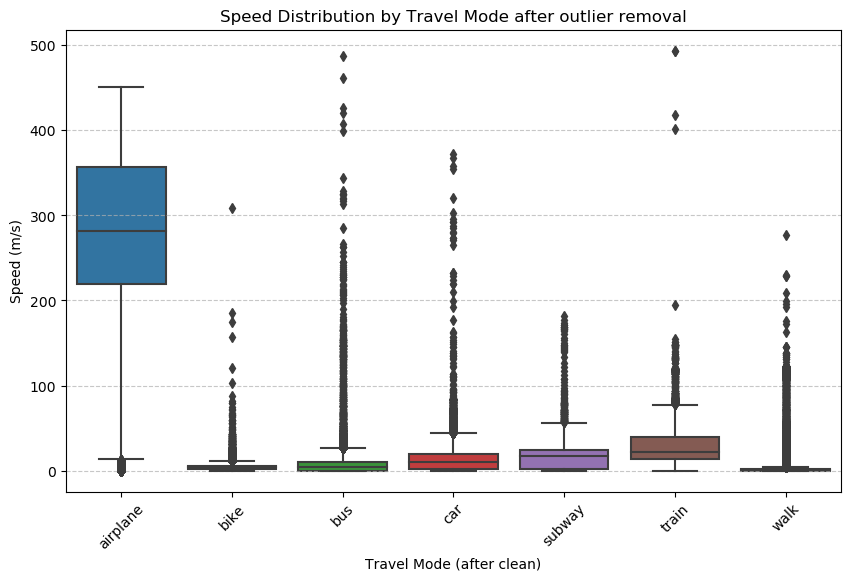

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_clean = df_features[(df_features['speed_filtered'].notna())& (df_features['accel_filtered'].notna()) & (df_features['vspeed_filtered'].notna()) & (~df_features['alt_outlier'])]

plt.figure(figsize=(10, 6))
sns.boxplot(x='modes', y='speed_filtered', data=df_clean)

plt.title("Speed Distribution by Travel Mode after outlier removal")
plt.xlabel("Travel Mode (after clean)")
plt.ylabel("Speed (m/s)")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

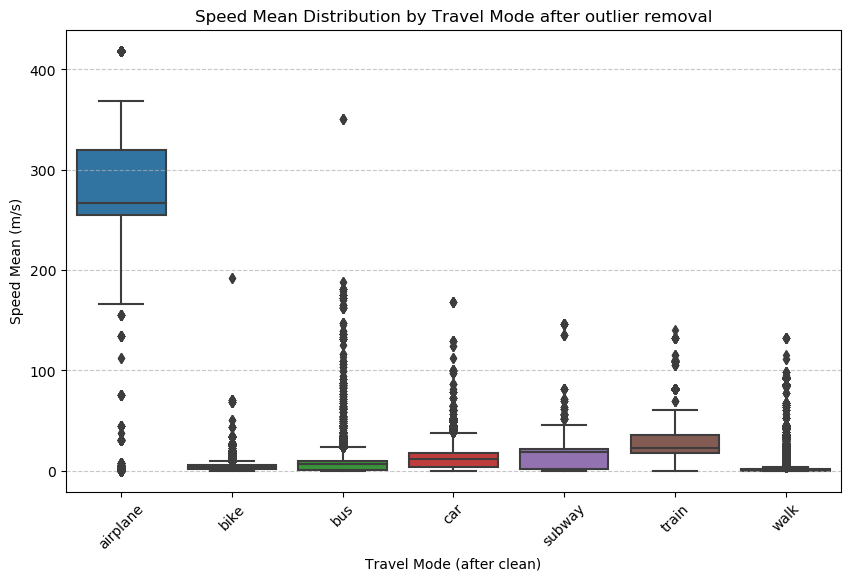

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_clean = df_features[(df_features['speed_filtered'].notna())& (df_features['accel_filtered'].notna()) & (df_features['vspeed_filtered'].notna()) & (~df_features['alt_outlier'])]

plt.figure(figsize=(10, 6))
sns.boxplot(x='modes', y='speed_mean', data=df_clean)

plt.title("Speed Mean Distribution by Travel Mode after outlier removal")
plt.xlabel("Travel Mode (after clean)")
plt.ylabel("Speed Mean (m/s)")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

## Acceleration features

In [ ]:
from scipy.stats import skew, kurtosis
def apply_acceleration_features(original_df):

  def calculate_accel_features(df):
    # Define the list of percentile values to calculate
    percentiles = [10, 30, 50, 70, 95]

    # Create an aggregation dictionary for all required statistics
    agg_dict = {
      'accel_mean': ('accel_filtered', 'mean'),
      'accel_std': ('accel_filtered', 'std'),
      'accel_skew': ('accel_filtered', lambda x: skew(x.dropna())),
      'accel_kurt': ('accel_filtered', lambda x: kurtosis(x.dropna())),
      }

    # Add percentile calculations to the aggregation dictionary
    for p in percentiles:
      agg_dict[f'accel_p{p}'] = ('accel_filtered', lambda x, p=p: np.nanpercentile(x, p))

    # Perform the grouped aggregation
    feature_df = df.groupby('seg_id_time_split').agg(
      **agg_dict
      ).reset_index()
    return feature_df

  feature_df = calculate_accel_features(original_df)

  merged_df = pd.merge(original_df, feature_df,on='seg_id_time_split',how='left')

  return merged_df

In [ ]:
df_features = apply_acceleration_features(df_features)

/tmp/ipykernel_93819/3448731986.py:12: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  'accel_skew': ('accel_filtered', lambda x: skew(x.dropna())),
/home/linuxuser/.local/lib/python3.8/site-packages/scipy/stats/_stats_py.py:1304: RuntimeWarning: Mean of empty slice.
  mean = a.mean(axis, keepdims=True)
/home/linuxuser/.local/lib/python3.8/site-packages/numpy/core/_methods.py:182: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/linuxuser/.local/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/linuxuser/.local/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_93819/3448731986.py:13: RuntimeWarning: Precision los

In [ ]:
accel_column = ['datetime','trip_id','modes','lon','lat','dt_sec','accel','is_stop','to_remove','orientation_drop','seg_id_time_split','speed_filtered','accel_filtered','accel_mean','accel_std','accel_skew']
df_features[accel_column]

,datetime,trip_id,modes,lon,lat,dt_sec,accel,is_stop,to_remove,orientation_drop,seg_id_time_split,speed_filtered,accel_filtered,accel_mean,accel_std,accel_skew
0,2008-12-01 07:49:36,<NA>,NaN,116.420565,39.993189,NaN,NaN,False,False,False,1_0,0.000000,NaN,-0.541391,4.776911,-1.014994
1,2008-12-01 07:49:38,<NA>,NaN,116.417182,39.995136,2.0,4.333747,False,True,True,1_0,8.667494,4.333747,-0.541391,4.776911,-1.014994
2,2008-12-01 07:49:40,<NA>,NaN,116.412568,39.997684,2.0,46.773073,False,True,True,1_0,102.213640,NaN,-0.541391,4.776911,-1.014994
3,2008-12-01 07:49:42,<NA>,NaN,116.414270,39.996701,2.0,-16.367643,False,True,True,1_0,69.478354,-16.367643,-0.541391,4.776911,-1.014994
4,2008-12-01 07:49:44,<NA>,NaN,116.420262,39.993076,2.0,-6.394855,False,True,True,1_0,56.688644,-6.394855,-0.541391,4.776911,-1.014994
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5953517,2008-11-29 16:15:52,<NA>,NaN,116.319362,40.007802,2.0,0.297488,False,False,False,639756_0,1.274710,0.297488,0.097740,0.135793,0.830574
5953518,2008-11-29 16:15:54,<NA>,NaN,116.319360,40.007780,2.0,0.121074,False,False,False,639756_0,1.516859,0.121074,0.097740,0.135793,0.830574
5953519,2008-11-29 16:15:56,<NA>,NaN,116.319362,40.007756,2.0,0.055928,False,False,False,639756_0,1.628715,0.055928,0.097740,0.135793,0.830574
5953520,2008-11-29 16:15:58,<NA>,NaN,116.319361,40.007740,2.0,-0.012407,False,False,False,639756_0,1.603901,-0.012407,0.097740,0.135793,0.830574


## Heading Features - Yaw
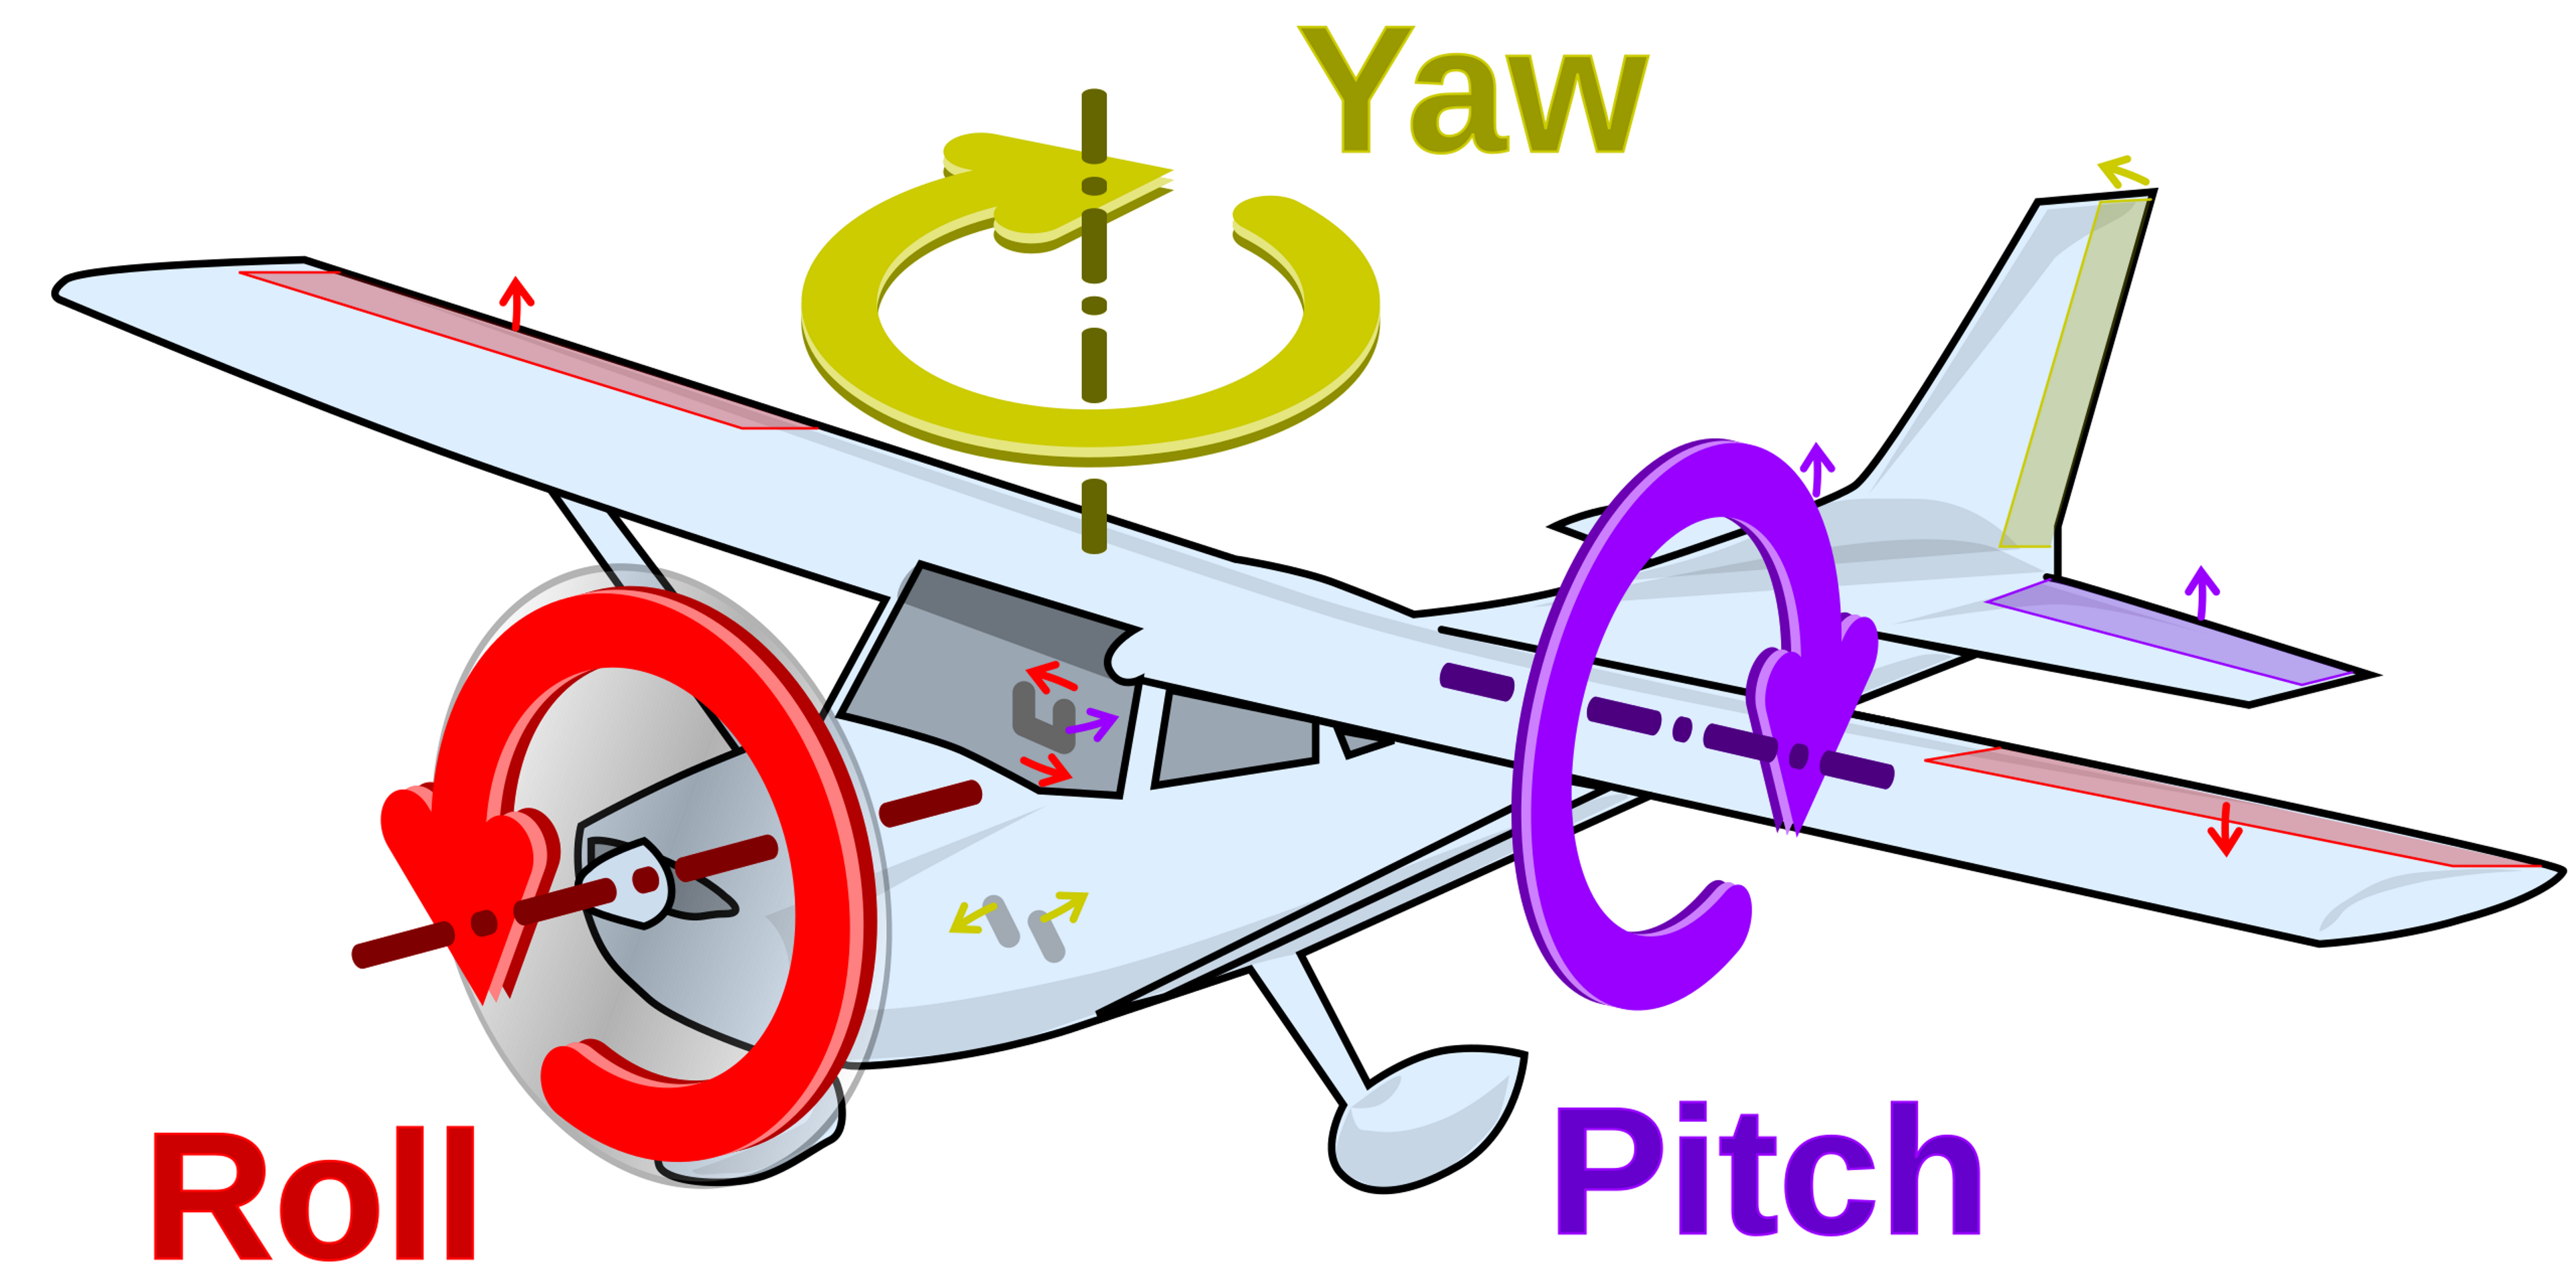

For heading features, the heading change will make more sense

In [ ]:
df_features = df_features.drop(columns=['lon','lat','x','y','stop_group_local','stop_group','dist_2pts','dt_heading','user_id'])

In [ ]:
df_features['yaw'] = (df_features['heading_smooth'] - df_features['heading_smooth'].shift(1))/df_features['dt_sec']

In [ ]:
from scipy.stats import skew, kurtosis
def apply_head_features(original_df):

  def calculate_head_features(df):
    # Define the list of percentile values to calculate
    percentiles = [10, 30, 50, 70, 95]

    # Create an aggregation dictionary for all required statistics
    agg_dict = {
      'yaw_mean': ('yaw', 'mean'),
      'yaw_std': ('yaw', 'std'),
      'yaw_skew': ('yaw', lambda x: skew(x.dropna())),
      'yaw_kurt': ('yaw', lambda x: kurtosis(x.dropna())),
      }

    # Add percentile calculations to the aggregation dictionary
    for p in percentiles:
      agg_dict[f'yaw_p{p}'] = ('yaw', lambda x, p=p: np.nanpercentile(x, p) if x.dropna().size > 0 else np.nan)

    # Perform the grouped aggregation
    feature_df = df.groupby('seg_id_time_split').agg(
      **agg_dict
      ).reset_index()
    return feature_df

  feature_df = calculate_head_features(original_df)
  merged_df = pd.merge(original_df,feature_df,on='seg_id_time_split',how='left')

  return merged_df

In [ ]:
df_features = apply_head_features(df_features)

/tmp/ipykernel_93819/2387277875.py:12: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  'yaw_skew': ('yaw', lambda x: skew(x.dropna())),
/home/linuxuser/.local/lib/python3.8/site-packages/scipy/stats/_stats_py.py:1304: RuntimeWarning: Mean of empty slice.
  mean = a.mean(axis, keepdims=True)
/home/linuxuser/.local/lib/python3.8/site-packages/numpy/core/_methods.py:182: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/linuxuser/.local/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/linuxuser/.local/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_93819/2387277875.py:13: RuntimeWarning: Precision loss occurred in

In [ ]:
head_column = ['datetime','trip_id','modes','dt_sec','is_stop','to_remove','orientation_drop','seg_id_time_split','heading_smooth','yaw','yaw_mean','yaw_std','yaw_skew']
df_features[head_column]

,datetime,trip_id,modes,dt_sec,is_stop,to_remove,orientation_drop,seg_id_time_split,heading_smooth,yaw,yaw_mean,yaw_std,yaw_skew
0,2008-12-01 07:49:36,<NA>,NaN,NaN,False,False,False,1_0,0.000000,NaN,-1.032716,28.801005,-2.391709
1,2008-12-01 07:49:38,<NA>,NaN,2.0,False,True,True,1_0,143.085030,71.542515,-1.032716,28.801005,-2.391709
2,2008-12-01 07:49:40,<NA>,NaN,2.0,False,True,True,1_0,144.112054,0.513512,-1.032716,28.801005,-2.391709
3,2008-12-01 07:49:42,<NA>,NaN,2.0,False,True,True,1_0,144.742337,0.315141,-1.032716,28.801005,-2.391709
4,2008-12-01 07:49:44,<NA>,NaN,2.0,False,True,True,1_0,-40.968627,-92.855482,-1.032716,28.801005,-2.391709
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5953517,2008-11-29 16:15:52,<NA>,NaN,2.0,False,False,False,639756_0,-86.661955,-1.368495,-5.483653,14.657749,-2.258612
5953518,2008-11-29 16:15:54,<NA>,NaN,2.0,False,False,False,639756_0,-88.828762,-1.083404,-5.483653,14.657749,-2.258612
5953519,2008-11-29 16:15:56,<NA>,NaN,2.0,False,False,False,639756_0,-88.856535,-0.013886,-5.483653,14.657749,-2.258612
5953520,2008-11-29 16:15:58,<NA>,NaN,2.0,False,False,False,639756_0,-89.244867,-0.194166,-5.483653,14.657749,-2.258612


## Global features

Straight rate and stop rate

In [ ]:
feature_df = df_features.groupby('seg_id').agg(SR=('is_stop', lambda x: x.mean())).reset_index()
df_features = pd.merge(df_features, feature_df, on='seg_id',how='left')

In [ ]:
df_features[df_features['seg_id']==2033][['datetime','trip_id','modes','dt_sec','is_stop','to_remove','orientation_drop','seg_id','seg_id_time_split','heading_smooth','speed_filtered','yaw','SR']]

,datetime,trip_id,modes,dt_sec,is_stop,to_remove,orientation_drop,seg_id,seg_id_time_split,heading_smooth,speed_filtered,yaw,SR
13800,2008-12-03 17:18:38,006_00263,bike,2.0,False,False,False,2033,2033_0,0.000000,0.000000,0.000000,0.0
13801,2008-12-03 17:18:40,006_00263,bike,2.0,False,False,False,2033,2033_0,-84.526978,0.150342,-42.263489,0.0
13802,2008-12-03 17:18:42,006_00263,bike,2.0,False,False,False,2033,2033_0,-79.727587,1.094038,2.399695,0.0
13803,2008-12-03 17:18:44,006_00263,bike,2.0,False,False,False,2033,2033_0,-82.841449,2.164600,-1.556931,0.0
13804,2008-12-03 17:18:46,006_00263,bike,2.0,False,False,False,2033,2033_0,-79.709392,2.669236,1.566028,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13907,2008-12-03 17:22:12,006_00263,bike,2.0,False,False,False,2033,2033_0,-84.890119,4.430520,0.146689,0.0
13908,2008-12-03 17:22:14,006_00263,bike,2.0,False,False,False,2033,2033_0,-84.634698,4.321605,0.127710,0.0
13909,2008-12-03 17:22:16,006_00263,bike,2.0,False,False,False,2033,2033_0,-84.575736,4.140022,0.029481,0.0
13910,2008-12-03 17:22:18,006_00263,bike,2.0,False,False,False,2033,2033_0,-82.869050,3.706311,0.853343,0.0


In [ ]:
def apply_straight_rate(df):
  # Extract start and end points per segment
  od_pair = (
    df.groupby('seg_id').agg(
        x_start=('x_smooth', 'first'),
        y_start=('y_smooth', 'first'),
        x_end=('x_smooth', 'last'),
        y_end=('y_smooth', 'last'),
        dis_total=('distance', 'sum')
        )
    .reset_index()
    )

  # Compute OD distance
  od_pair['dis_od'] = np.sqrt(
        (od_pair['x_end'] - od_pair['x_start'])**2 +
        (od_pair['y_end'] - od_pair['y_start'])**2
    )

  # Compute straightness
  od_pair['straight_rate'] = od_pair['dis_od'] / od_pair['dis_total']

  # Merge back
  return df.merge(od_pair[['seg_id', 'straight_rate']], on='seg_id', how='left')

In [ ]:
df_features = apply_straight_rate(df_features)

In [ ]:
head_column = ['datetime','trip_id','modes','dt_sec','is_stop','to_remove','orientation_drop','seg_id_time_split','SR','straight_rate']
df_features[head_column]

,datetime,trip_id,modes,dt_sec,is_stop,to_remove,orientation_drop,seg_id_time_split,SR,straight_rate
0,2008-12-01 07:49:36,<NA>,NaN,NaN,False,False,False,1_0,0.021739,0.033169
1,2008-12-01 07:49:38,<NA>,NaN,2.0,False,True,True,1_0,0.021739,0.033169
2,2008-12-01 07:49:40,<NA>,NaN,2.0,False,True,True,1_0,0.021739,0.033169
3,2008-12-01 07:49:42,<NA>,NaN,2.0,False,True,True,1_0,0.021739,0.033169
4,2008-12-01 07:49:44,<NA>,NaN,2.0,False,True,True,1_0,0.021739,0.033169
...,...,...,...,...,...,...,...,...,...,...
5953517,2008-11-29 16:15:52,<NA>,NaN,2.0,False,False,False,639756_0,0.000000,0.940714
5953518,2008-11-29 16:15:54,<NA>,NaN,2.0,False,False,False,639756_0,0.000000,0.940714
5953519,2008-11-29 16:15:56,<NA>,NaN,2.0,False,False,False,639756_0,0.000000,0.940714
5953520,2008-11-29 16:15:58,<NA>,NaN,2.0,False,False,False,639756_0,0.000000,0.940714


In [ ]:
df_features.columns

Index(['datetime', 'file_name', 'modes', 'trip_id', 'dt_sec', 'heading',
       'distance', 'alt_m', 'speed', 'to_remove', 'is_stop', 'seg_id',
       'orientation_drop', 'seg_id_time_split', 'x_smooth', 'y_smooth',
       'vx_smooth', 'vy_smooth', 'alt_m_smooth', 'vz_smooth', 'speed_smooth',
       'distance_smooth', 'heading_smooth', 'accel', 'ver_speed',
       'alt_outlier', 'speed_filtered', 'accel_filtered', 'vspeed_filtered',
       'speed_outlier', 'speed_mean', 'speed_std', 'speed_skew', 'speed_kurt',
       'speed_p10', 'speed_p30', 'speed_p50', 'speed_p70', 'speed_p95',
       'accel_mean', 'accel_std', 'accel_skew', 'accel_kurt', 'accel_p10',
       'accel_p30', 'accel_p50', 'accel_p70', 'accel_p95', 'yaw', 'yaw_mean',
       'yaw_std', 'yaw_skew', 'yaw_kurt', 'yaw_p10', 'yaw_p30', 'yaw_p50',
       'yaw_p70', 'yaw_p95', 'SR', 'straight_rate'],
      dtype='object')

## GIS features

Extract bus and metro stations from OpenStreetMap (limited to Beijing)

In [ ]:
# import necessay libraries of your choice
!pip install osmnx
!pip install overpy
!pip install contextily
import osmnx
import pyproj
import overpy
import numpy as np
import contextily as ctx
import shapely
from shapely.ops import unary_union, polygonize
from shapely.geometry import Point, LineString, Polygon
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
crs_gps = pyproj.CRS.from_epsg('4326')  # Merkator
crs_web = pyproj.CRS.from_epsg('3857')  # Pseudo-Merkator
gdf_beijing = osmnx.geocode_to_gdf("Beijing, China")
gdf_beijing

,geometry,bbox_north,bbox_south,bbox_east,bbox_west,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"MULTIPOLYGON (((115.41721 39.96842, 115.42060 ...",41.059558,39.17071,117.737124,115.417209,203711638,relation,912940,40.190632,116.412144,boundary,administrative,8,0.788201,state,Beijing,"Beijing, China"


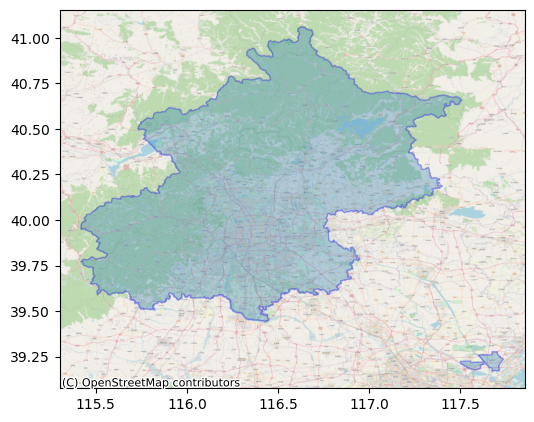

In [ ]:
# plot districts
ax = gdf_beijing.plot(edgecolor='blue', alpha=.3, figsize=(6, 6))

# add base map
ctx.add_basemap(ax=ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=11, crs=crs_gps)

In [ ]:
beijing = unary_union(list(gdf_beijing.to_crs(crs=crs_gps).geometry))

extract bus station from OSM

In [ ]:
bus_stops = osmnx.features_from_polygon(beijing,tags={"highway": "bus_stop"})

/home/linuxuser/.local/lib/python3.8/site-packages/osmnx/_overpass.py:254: UserWarning: This area is 11 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


In [ ]:
display(bus_stops[~bus_stops.geometry.is_valid])

,,highway,geometry,bench,bus,name,public_transport,shelter,nodes,layer,name:en,...,description,key,check_date:lit,int_name,old_name:en,old_name:zh,level,name:de,surface,wikimedia_commons
element_type,osmid,,,,,,,,,,,,,,,,,,,,,


In [ ]:
bus_stops = bus_stops[['name','highway','geometry']]
bus_stops = bus_stops.to_crs(crs=crs_web)

In [ ]:
(bus_stops.geometry.type != "Point").sum()

5

In [ ]:
bus_stops = bus_stops[bus_stops.geometry.type=="Point"]

Extract metro stations from OSM

In [ ]:
metro_entrance = osmnx.features_from_polygon(beijing,tags={"railway": "subway_entrance"})

/home/linuxuser/.local/lib/python3.8/site-packages/osmnx/_overpass.py:254: UserWarning: This area is 11 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


In [ ]:
metro_entrance = metro_entrance[['name','railway','geometry']]
metro_entrance = metro_entrance.to_crs(crs=crs_web)

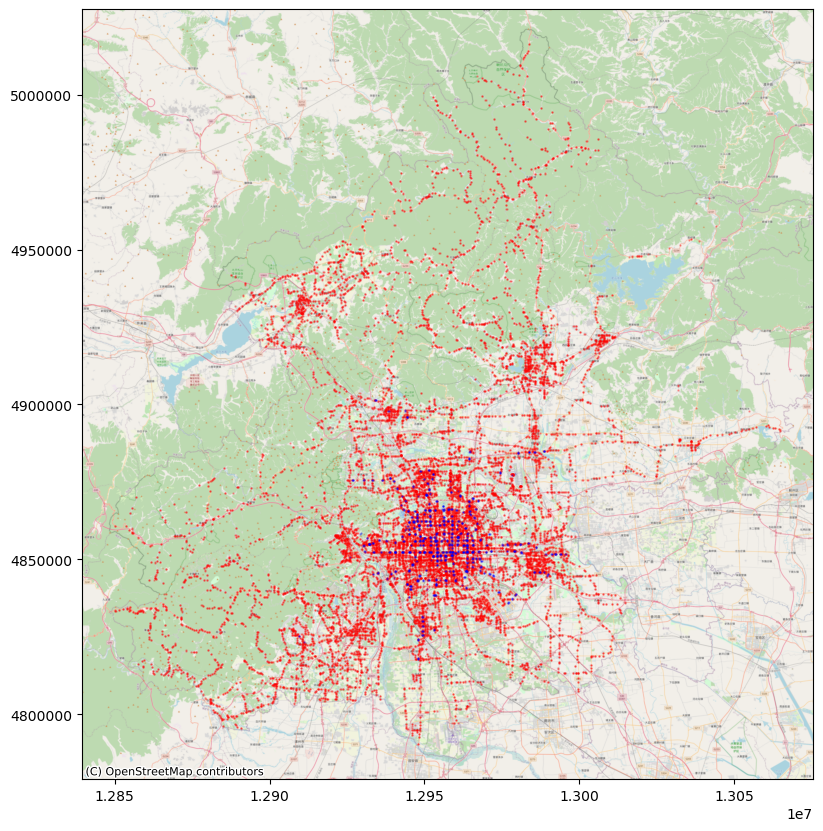

In [ ]:
# plot bus stops and metro stations
fig, ax = plt.subplots(figsize=(10,10))
bus_stops.plot(ax=ax,markersize=0.5, color='red', alpha=.3)
metro_entrance.plot(ax=ax, markersize=0.5, color='blue', alpha=.3)

# add base map
ctx.add_basemap(ax=ax,source=ctx.providers.OpenStreetMap.Mapnik, zoom=11, crs=crs_web)


In [ ]:
# keep the original index as a new column for merge later
df_features = df_features.reset_index(drop=False, names='idx_o')
df_features.columns

Index(['idx_o', 'datetime', 'file_name', 'modes', 'trip_id', 'dt_sec',
       'heading', 'distance', 'alt_m', 'speed', 'to_remove', 'is_stop',
       'seg_id', 'orientation_drop', 'seg_id_time_split', 'x_smooth',
       'y_smooth', 'vx_smooth', 'vy_smooth', 'alt_m_smooth', 'vz_smooth',
       'speed_smooth', 'distance_smooth', 'heading_smooth', 'accel',
       'ver_speed', 'alt_outlier', 'speed_filtered', 'accel_filtered',
       'vspeed_filtered', 'speed_outlier', 'speed_mean', 'speed_std',
       'speed_skew', 'speed_kurt', 'speed_p10', 'speed_p30', 'speed_p50',
       'speed_p70', 'speed_p95', 'accel_mean', 'accel_std', 'accel_skew',
       'accel_kurt', 'accel_p10', 'accel_p30', 'accel_p50', 'accel_p70',
       'accel_p95', 'yaw', 'yaw_mean', 'yaw_std', 'yaw_skew', 'yaw_kurt',
       'yaw_p10', 'yaw_p30', 'yaw_p50', 'yaw_p70', 'yaw_p95', 'SR',
       'straight_rate'],
      dtype='object')

In [ ]:
gdf_features =gpd.GeoDataFrame(
    df_features.assign(geometry=\
              df_features[['x_smooth','y_smooth']]\
              .apply(tuple, axis=1)\
              .apply(shapely.geometry.Point)
                   ),
    crs=crs_web)

In [ ]:
gdf_features = gdf_features[gdf_features.geometry.is_valid]

In [ ]:
# find nearest bus staion within 100 m
gdf_bus = gdf_features.sjoin_nearest(bus_stops, distance_col='dist_bus', max_distance=100, how='left')

In [ ]:
gdf_bus[(gdf_bus['dist_bus'].notna())&(gdf_bus['modes']=='bus')]

,idx_o,datetime,file_name,modes,trip_id,dt_sec,heading,distance,alt_m,speed,...,yaw_p70,yaw_p95,SR,straight_rate,geometry,index_right0,index_right1,name,highway,dist_bus
72078,72078,2008-11-30 10:58:20,11.plt,bus,006_00249,2.0,-176.731886,17.840132,0.0,8.920066,...,0.049601,0.389364,0.000000,1.017097,POINT (12959225.463 4864155.269),node,9.701084e+09,惠新东桥西,bus_stop,40.597327
72079,72079,2008-11-30 10:58:22,11.plt,bus,006_00249,2.0,-175.407958,29.036274,0.0,14.518137,...,0.049601,0.389364,0.000000,1.017097,POINT (12959203.658 4864154.250),node,9.701084e+09,惠新东桥西,bus_stop,19.365318
72080,72080,2008-11-30 10:58:24,11.plt,bus,006_00249,2.0,178.269488,24.055981,0.0,12.027991,...,0.049601,0.389364,0.000000,1.017097,POINT (12959181.048 4864153.780),node,9.701084e+09,惠新东桥西,bus_stop,7.334884
72081,72081,2008-11-30 10:58:26,11.plt,bus,006_00249,2.0,180.000000,23.711052,0.0,11.855526,...,0.049601,0.389364,0.000000,1.017097,POINT (12959157.955 4864153.488),node,9.701084e+09,惠新东桥西,bus_stop,27.913729
72082,72082,2008-11-30 10:58:28,11.plt,bus,006_00249,2.0,175.629437,24.785001,0.0,12.392500,...,0.049601,0.389364,0.000000,1.017097,POINT (12959134.199 4864153.900),node,9.701084e+09,惠新东桥西,bus_stop,51.278439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734258,5734258,2008-04-02 18:05:20,PPG_20080401032546.plt,bus,031_00062,3.0,-31.567062,7.407990,0.0,2.469330,...,0.644090,3.898157,0.016667,0.626851,POINT (12952210.006 4861035.122),node,9.699432e+09,蓟门桥东,bus_stop,24.342062
5734259,5734259,2008-04-02 18:05:25,PPG_20080401032546.plt,bus,031_00062,5.0,26.543851,4.355259,0.0,0.871052,...,0.644090,3.898157,0.016667,0.626851,POINT (12952220.882 4861036.583),node,9.699432e+09,蓟门桥东,bus_stop,18.512240
5734260,5734260,2008-04-02 18:05:30,PPG_20080401032546.plt,bus,031_00062,5.0,-117.866609,27.388402,0.0,5.477680,...,0.644090,3.898157,0.016667,0.626851,POINT (12952213.260 4861024.724),node,9.699432e+09,蓟门桥东,bus_stop,16.499783
5734261,5734261,2008-04-02 18:05:33,PPG_20080401032546.plt,bus,031_00062,3.0,44.935686,13.366515,0.0,4.455505,...,0.644090,3.898157,0.016667,0.626851,POINT (12952208.327 4861022.403),node,9.699432e+09,蓟门桥东,bus_stop,20.876461


In [ ]:
features_to_merge = gdf_bus[['idx_o','dist_bus']]
df_features = df_features.merge(
    features_to_merge,
    on='idx_o',
    how='left'
)

In [ ]:
# find nearest metro staion within 100 m
gdf_metro = gdf_features.sjoin_nearest(metro_entrance, distance_col='dist_metro', max_distance=100, how='left')

In [ ]:
gdf_metro[gdf_metro['dist_metro'].notna()]

,idx_o,user_id,lat,lon,datetime,file_name,modes,trip_id,dt_sec,x,...,vz_smooth,speed_smooth,distance_smooth,heading_smooth,geometry,element,id,name,railway,dist_metro
6071,6071,6,39.968416,116.411888,2008-12-02 16:56:35,1-7.plt,NaN,NaN,27050.0,1.295891e+07,...,0.0,0.000000,0.000000,0.000000,POINT (12958912.094 4861353.64),node,1.240946e+10,和平西桥G出口,subway_entrance,29.007444
6072,6072,6,39.968397,116.411845,2008-12-02 16:56:37,1-7.plt,NaN,NaN,2.0,1.295891e+07,...,0.0,0.000000,0.000000,0.000000,POINT (12958907.308 4861350.88),node,1.240946e+10,和平西桥G出口,subway_entrance,29.935365
6073,6073,6,39.968450,116.411868,2008-12-02 16:56:39,1-7.plt,bike,006_00259,2.0,1.295891e+07,...,0.0,0.149289,0.298578,71.603491,POINT (12958909.753 4861358.232),node,1.240946e+10,和平西桥G出口,subway_entrance,34.126909
6074,6074,6,39.968474,116.411864,2008-12-02 16:56:41,1-7.plt,bike,006_00259,2.0,1.295891e+07,...,0.0,0.663018,1.326037,91.313281,POINT (12958909.573 4861360.805),node,1.240946e+10,和平西桥G出口,subway_entrance,36.400438
6075,6075,6,39.968525,116.411889,2008-12-02 16:56:43,1-7.plt,bike,006_00259,2.0,1.295891e+07,...,0.0,1.819283,3.638567,77.653030,POINT (12958911.249 4861366.834),node,1.240946e+10,和平西桥G出口,subway_entrance,40.942891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498364,498364,6,39.956921,116.481599,2009-09-13 20:33:27,9.plt,bus,006_00971,2.0,1.296667e+07,...,0.0,7.319336,14.638672,116.292680,POINT (12966684.047 4859664.584),node,6.782763e+09,NaN,subway_entrance,97.245094
498365,498365,6,39.957111,116.481446,2009-09-13 20:33:29,9.plt,bus,006_00971,2.0,1.296666e+07,...,0.0,8.293973,16.587945,117.114388,POINT (12966671.149 4859687.488),node,6.782763e+09,NaN,subway_entrance,83.938162
498366,498366,6,39.957304,116.481296,2009-09-13 20:33:31,9.plt,bus,006_00971,2.0,1.296664e+07,...,0.0,9.375531,18.751061,117.879649,POINT (12966656.404 4859713.016),node,6.782763e+09,NaN,subway_entrance,77.688004
498367,498367,6,39.957492,116.481142,2009-09-13 20:33:33,9.plt,bus,006_00971,2.0,1.296662e+07,...,0.0,10.472093,20.944187,118.627311,POINT (12966640.114 4859740.337),node,6.782763e+09,NaN,subway_entrance,83.447678


In [ ]:
features_to_merge = gdf_metro[['idx_o','dist_metro']]
df_features = df_features.merge(
    features_to_merge,
    on='idx_o',
    how='left'
)

In [ ]:
df_features

,idx_o,datetime,file_name,modes,trip_id,dt_sec,heading,distance,alt_m,speed,...,metro_std,metro_skew,metro_kurt,metro_p10,metro_p30,metro_p50,metro_p70,metro_p95,ratio_bus,ratio_metro
0,0,2008-12-01 07:49:36,1-7.plt,NaN,<NA>,NaN,NaN,NaN,0.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,1,2008-12-01 07:49:38,1-7.plt,NaN,<NA>,2.0,143.085030,471.020345,0.0000,235.510173,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,2,2008-12-01 07:49:40,1-7.plt,NaN,<NA>,2.0,144.214043,633.165177,0.0000,316.582589,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3,3,2008-12-01 07:49:42,1-7.plt,NaN,<NA>,2.0,-37.013173,237.277965,0.0000,118.638983,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4,4,2008-12-01 07:49:44,1-7.plt,NaN,<NA>,2.0,-38.297354,849.926287,0.0000,424.963144,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5953517,5953517,2008-11-29 16:15:52,20081129.plt,NaN,<NA>,2.0,-90.000000,3.778682,25.6032,1.889341,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
5953518,5953518,2008-11-29 16:15:54,20081129.plt,NaN,<NA>,2.0,-93.983216,3.205087,26.8224,1.602543,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
5953519,5953519,2008-11-29 16:15:56,20081129.plt,NaN,<NA>,2.0,-86.347778,3.495110,28.0416,1.747555,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
5953520,5953520,2008-11-29 16:15:58,20081129.plt,NaN,<NA>,2.0,-92.740791,2.328003,29.5656,1.164002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0


Features for Bus Stations

In [ ]:
from scipy.stats import skew, kurtosis
def apply_bus_features(original_df):

  def calculate_bus_features(df):
    # Define the list of percentile values to calculate
    percentiles = [10, 30, 50, 70, 95]

    # Create an aggregation dictionary for all required statistics
    agg_dict = {
      'bus_mean': ('dist_bus', 'mean'),
      'bus_std': ('dist_bus', 'std'),
      'bus_skew': ('dist_bus', lambda x: skew(x.dropna())),
      'bus_kurt': ('dist_bus', lambda x: kurtosis(x.dropna())),
      }

    # Add percentile calculations to the aggregation dictionary
    for p in percentiles:
      agg_dict[f'bus_p{p}'] = ('dist_bus', lambda x, p=p: np.nanpercentile(x, p))

    # Perform the grouped aggregation
    feature_df = df.groupby('seg_id_time_split').agg(
      **agg_dict
      ).reset_index()
    return feature_df

  feature_df = calculate_bus_features(original_df)

  merged_df = pd.merge(original_df, feature_df,on='seg_id_time_split',how='left')

  return merged_df

In [ ]:
df_features = apply_bus_features(df_features)

/home/linuxuser/.local/lib/python3.8/site-packages/scipy/stats/_stats_py.py:1304: RuntimeWarning: Mean of empty slice.
  mean = a.mean(axis, keepdims=True)
/home/linuxuser/.local/lib/python3.8/site-packages/numpy/core/_methods.py:182: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/linuxuser/.local/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/linuxuser/.local/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_102545/3971584456.py:12: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  'bus_skew': ('dist_bus', lambda x: skew(x.dropna())),
/home/linuxuser/.local/lib/python3.8/site-packages/scipy/stats/_stats_py.py

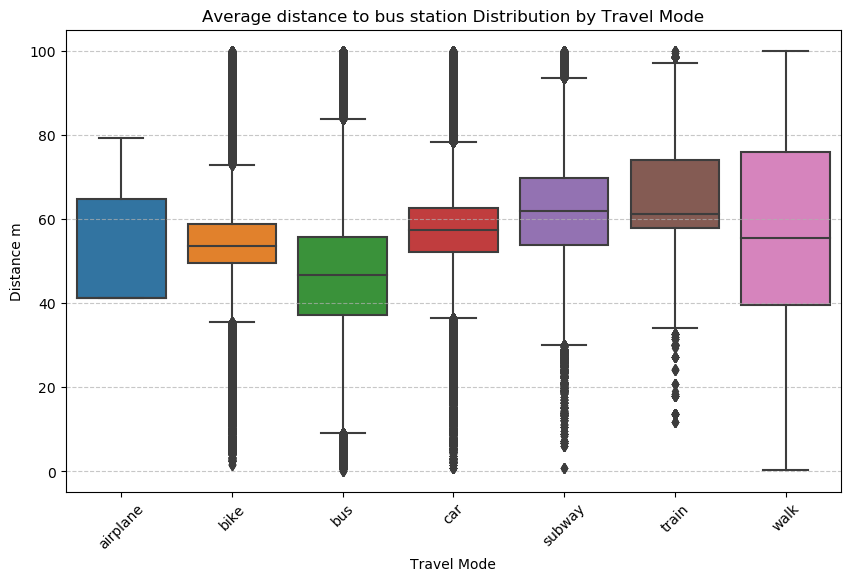

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='modes', y='bus_mean', data=df_features)

plt.title("Average distance to bus station Distribution by Travel Mode")
plt.xlabel("Travel Mode")
plt.ylabel("Distance m")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

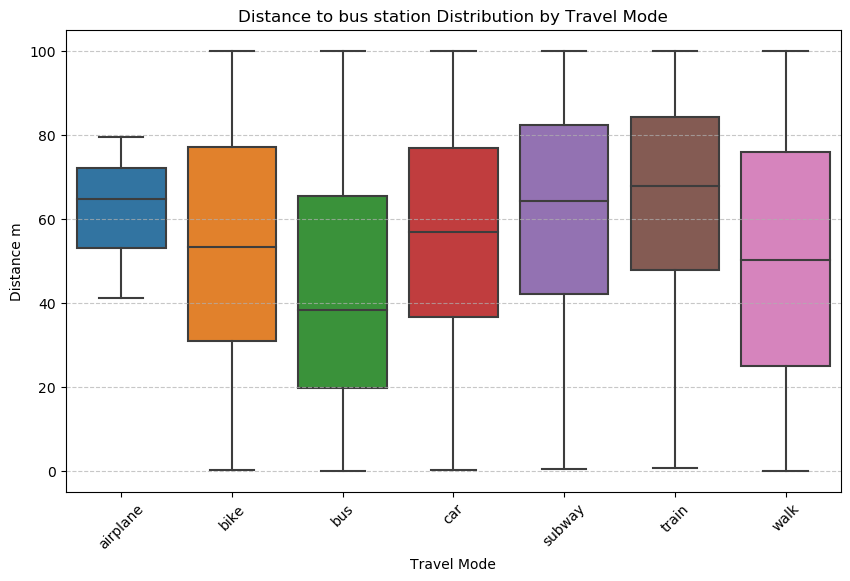

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='modes', y='dist_bus', data=df_features)

plt.title("Distance to bus station Distribution by Travel Mode")
plt.xlabel("Travel Mode")
plt.ylabel("Distance m")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

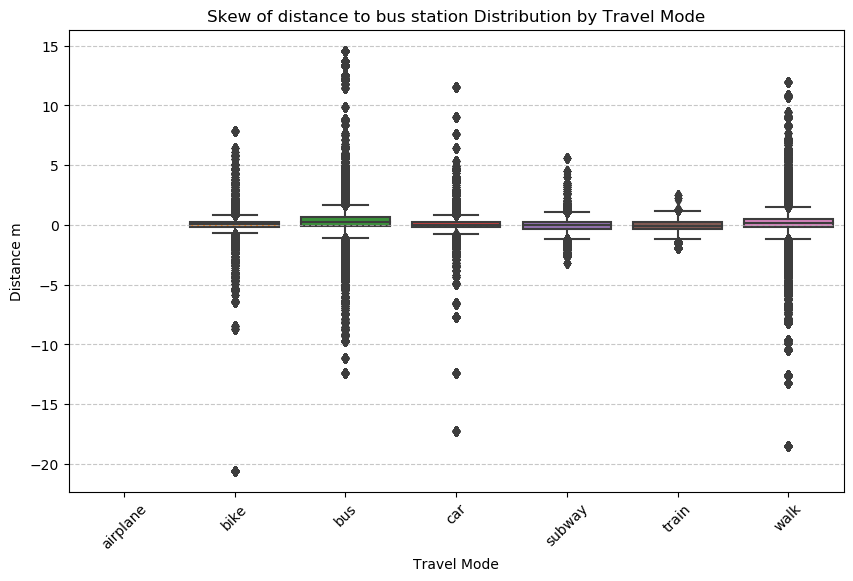

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='modes', y='bus_skew', data=df_features)

plt.title("Skew of distance to bus station Distribution by Travel Mode")
plt.xlabel("Travel Mode")
plt.ylabel("Distance m")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

Features for Metro Stations

In [ ]:
from scipy.stats import skew, kurtosis
def apply_metro_features(original_df):

  def calculate_metro_features(df):
    # Define the list of percentile values to calculate
    percentiles = [10, 30, 50, 70, 95]

    # Create an aggregation dictionary for all required statistics
    agg_dict = {
      'metro_mean': ('dist_metro', 'mean'),
      'metro_std': ('dist_metro', 'std'),
      'metro_skew': ('dist_metro', lambda x: skew(x.dropna())),
      'metro_kurt': ('dist_metro', lambda x: kurtosis(x.dropna())),
      }

    # Add percentile calculations to the aggregation dictionary
    for p in percentiles:
      agg_dict[f'metro_p{p}'] = ('dist_metro', lambda x, p=p: np.nanpercentile(x, p))

    # Perform the grouped aggregation
    feature_df = df.groupby('seg_id_time_split').agg(
      **agg_dict
      ).reset_index()
    return feature_df

  feature_df = calculate_metro_features(original_df)

  merged_df = pd.merge(original_df, feature_df,on='seg_id_time_split',how='left')

  return merged_df

In [ ]:
df_features = apply_metro_features(df_features)

/home/linuxuser/.local/lib/python3.8/site-packages/scipy/stats/_stats_py.py:1304: RuntimeWarning: Mean of empty slice.
  mean = a.mean(axis, keepdims=True)
/home/linuxuser/.local/lib/python3.8/site-packages/numpy/core/_methods.py:182: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/linuxuser/.local/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/linuxuser/.local/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_102545/667226170.py:12: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  'metro_skew': ('dist_metro', lambda x: skew(x.dropna())),
/home/linuxuser/.local/lib/python3.8/site-packages/scipy/stats/_stats_py

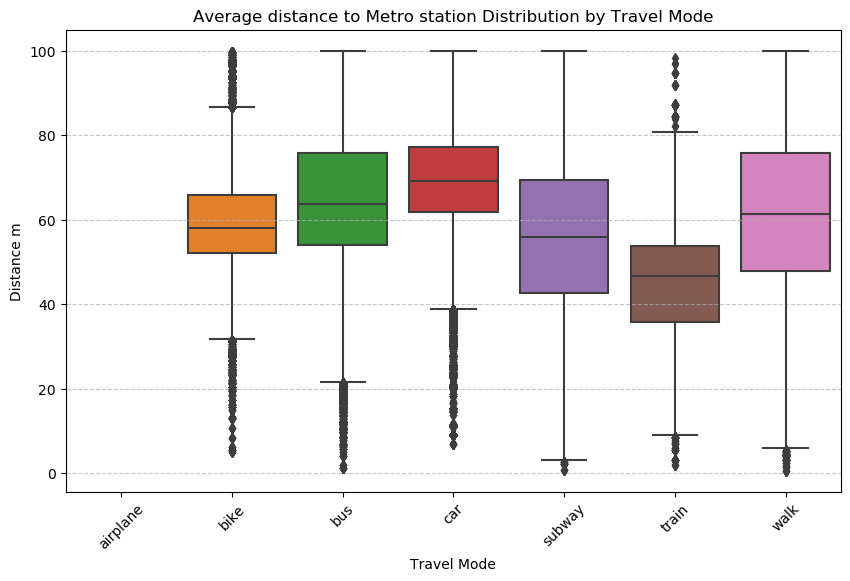

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='modes', y='metro_mean', data=df_features)

plt.title("Average distance to Metro station Distribution by Travel Mode")
plt.xlabel("Travel Mode")
plt.ylabel("Distance m")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

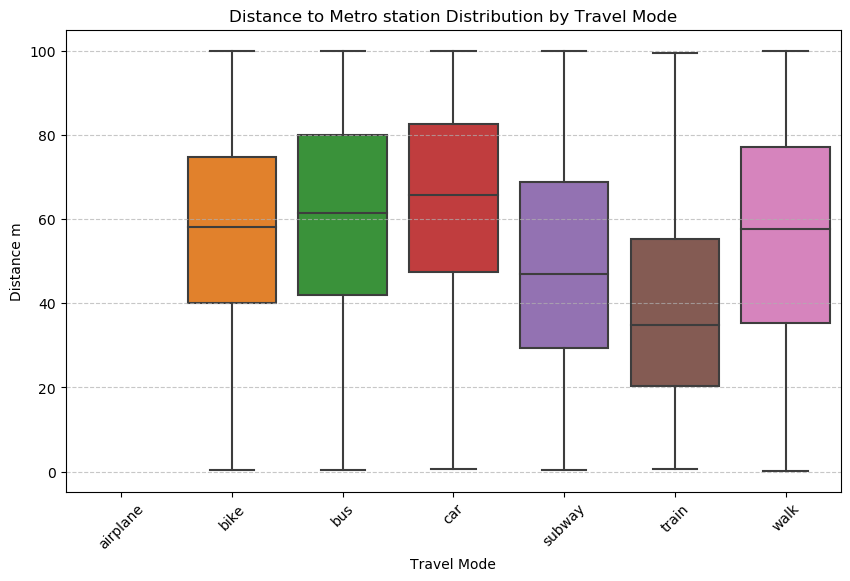

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='modes', y='dist_metro', data=df_features)

plt.title("Distance to Metro station Distribution by Travel Mode")
plt.xlabel("Travel Mode")
plt.ylabel("Distance m")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

extract some global features for bus and metros stations

In [ ]:
# calculate the ratio of stop point which is within 100m of the bus station per seg_id
def compute_ratio(g):
    total = g["is_stop"].sum()
    if total == 0:
        return 0
    return (g["is_stop"] & g["dist_bus"].notna()).sum() / total

ratio_bus = df_features.groupby("seg_id").apply(compute_ratio).reset_index(name="ratio_bus")

ratio_bus

,seg_id,ratio_bus
0,1,0.0
1,3,0.0
2,6,0.0
3,7,0.0
4,10,0.0
...,...,...
317403,639744,0.0
317404,639746,0.0
317405,639750,0.0
317406,639752,0.0


In [ ]:
df_features = df_features.merge(ratio_bus, on='seg_id',how='left')

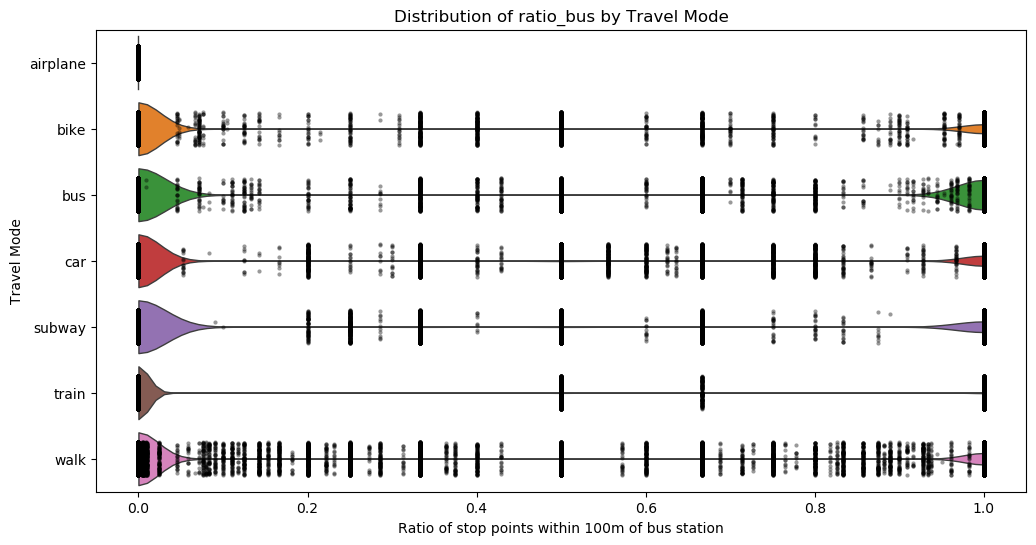

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Horizontal violin
sns.violinplot(
    data=df_features,
    x='ratio_bus',
    y='modes',
    inner=None,          # cleaner violin
    scale='width',
    cut=0,               # do not extend beyond data range
    linewidth=1
)

# Jittered points overlay
sns.stripplot(
    data=df_features,
    x='ratio_bus',
    y='modes',
    color='black',
    size=3,
    jitter=0.25,
    alpha=0.4
)

plt.xlabel("Ratio of stop points within 100m of bus station")
plt.ylabel("Travel Mode")
plt.title("Distribution of ratio_bus by Travel Mode")

plt.xlim(-0.05, 1.05)
plt.show()


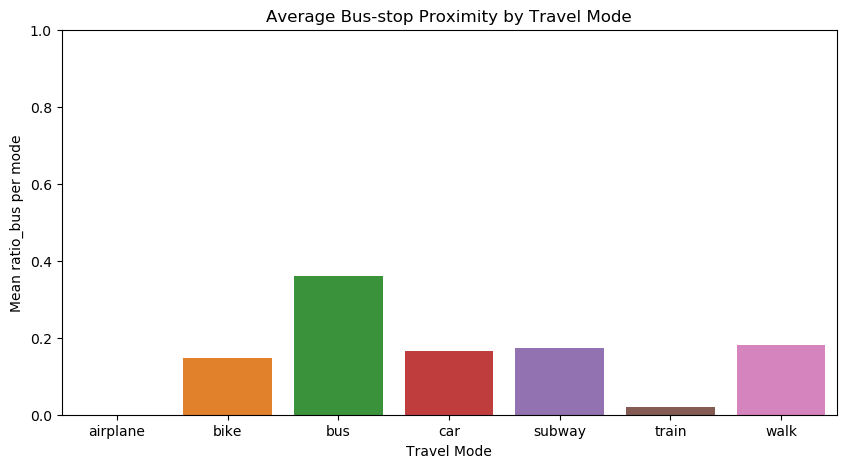

In [ ]:
mean_df = df_features.groupby('modes')['ratio_bus'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(
    data=mean_df,
    x='modes',
    y='ratio_bus'
)

plt.ylabel("Mean ratio_bus per mode")
plt.xlabel("Travel Mode")
plt.title("Average Bus-stop Proximity by Travel Mode")

plt.ylim(0,1)
plt.show()


In [ ]:
# calculate the ratio of stop point which is within 100m of the metro station per seg_id
def compute_ratio(g):
    total = g["is_stop"].sum()
    if total == 0:
        return 0
    return (g["is_stop"] & g["dist_metro"].notna()).sum() / total

ratio_metro = df_features.groupby("seg_id").apply(compute_ratio).reset_index(name="ratio_metro")

ratio_metro

,seg_id,ratio_metro
0,1,0.0
1,3,0.0
2,6,0.0
3,7,0.0
4,10,0.0
...,...,...
317403,639744,0.0
317404,639746,0.0
317405,639750,0.0
317406,639752,0.0


In [ ]:
df_features = df_features.merge(ratio_metro, on='seg_id',how='left')

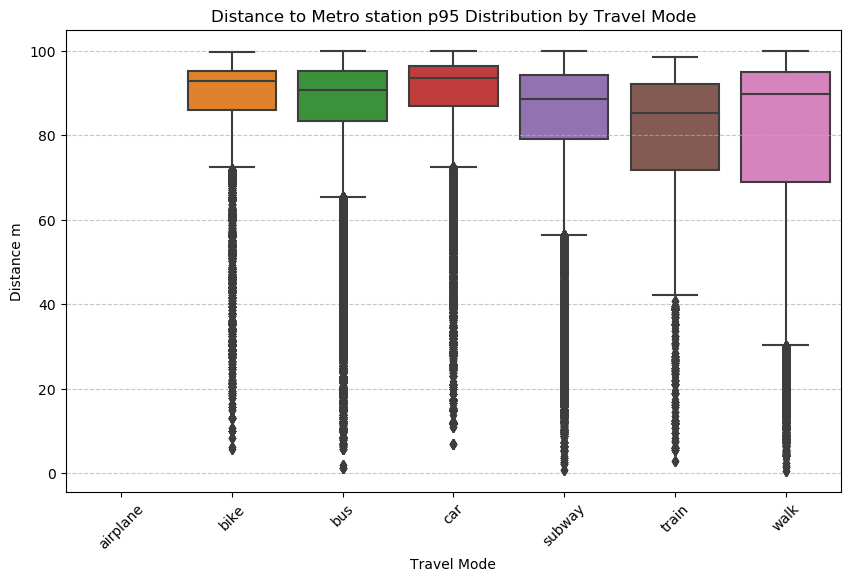

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='modes', y='metro_p95', data=df_features)

plt.title("Distance to Metro station p95 Distribution by Travel Mode")
plt.xlabel("Travel Mode")
plt.ylabel("Distance m")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()


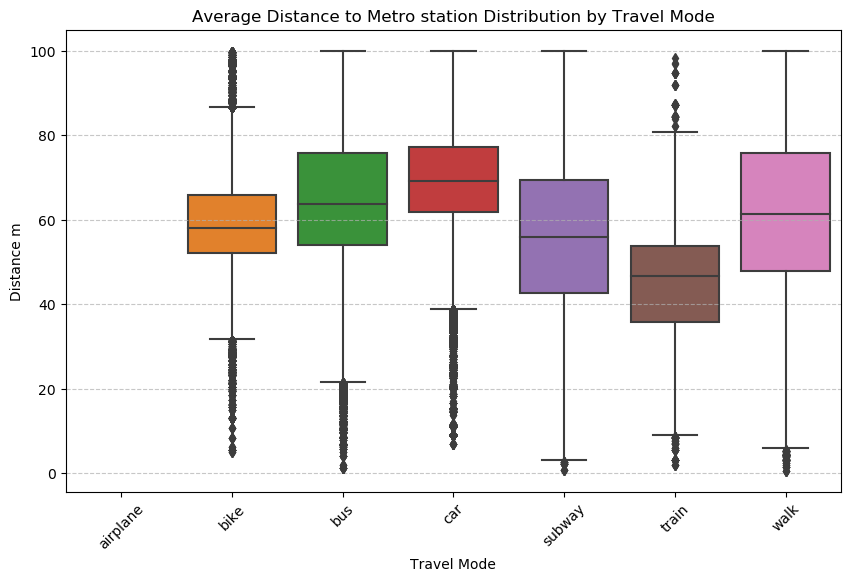

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='modes', y='metro_mean', data=df_features)

plt.title("Average Distance to Metro station Distribution by Travel Mode")
plt.xlabel("Travel Mode")
plt.ylabel("Distance m")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

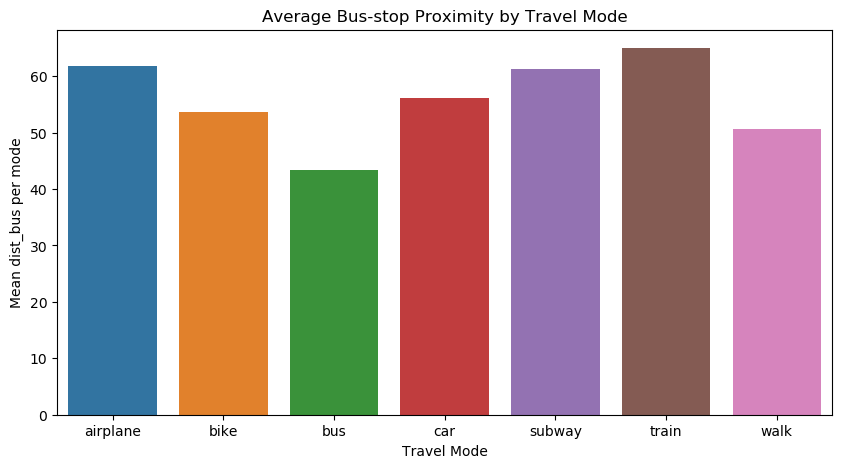

In [ ]:
mean_df = df_features.groupby('modes')['dist_bus'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(
    data=mean_df,
    x='modes',
    y='dist_bus'
)

plt.ylabel("Mean dist_bus per mode")
plt.xlabel("Travel Mode")
plt.title("Average Bus-stop Proximity by Travel Mode")

plt.show()

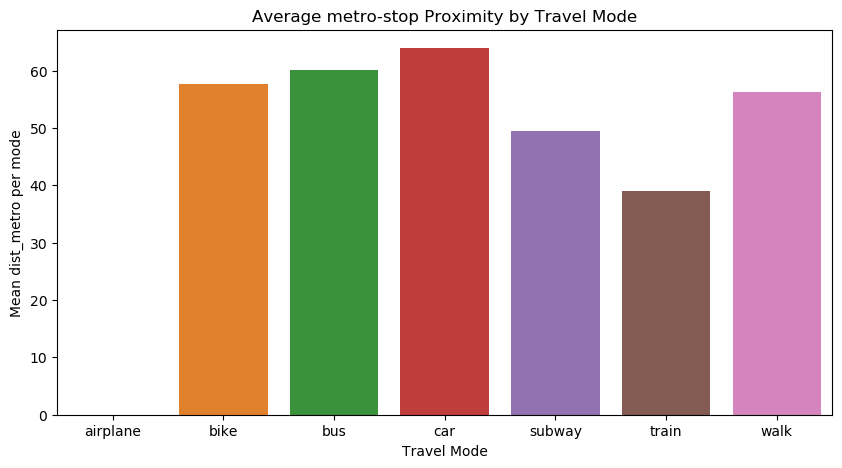

In [ ]:
mean_df = df_features.groupby('modes')['dist_metro'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(
    data=mean_df,
    x='modes',
    y='dist_metro'
)

plt.ylabel("Mean dist_metro per mode")
plt.xlabel("Travel Mode")
plt.title("Average metro-stop Proximity by Travel Mode")

plt.show()

Codes needs to be clear up

In [ ]:
import os
output_path = os.path.join(DATA_ROOT_DIR, 'df_features.csv')
print(f"\nSaving final dataset to '{output_path}'")
df_features.to_csv(output_path, index=False, na_rep="NaN")


Saving final dataset to '/home/linuxuser/Downloads/df_features.csv'


In [ ]:
DATA_ROOT_DIR = '/home/linuxuser/Downloads/'

In [ ]:
df_features = pd.read_csv(
    "/home/linuxuser/Downloads/df_features.csv",
    parse_dates=["datetime"],
    na_values=["NaN"],
    dtype={
        "file_name": "string",
        "modes": "category",
        "trip_id": "string",
        "seg_id": "Int64",
        "seg_id_time_split": "string"
    },
    low_memory=False
)

In [ ]:
df = pd.read_csv(
    "/home/linuxuser/Downloads/df_smooth.csv",
    parse_dates=["datetime"],
    na_values=["NaN"],
    dtype={
        "file_name": "string",
        "modes": "category",
        "trip_id": "string",
        "seg_id": "Int64",
        "seg_id_time_split": "string"
    },
    low_memory=False
)

In [ ]:
df.describe

<bound method NDFrame.describe of          user_id        lat         lon            datetime     file_name  \
0              6  39.993189  116.420565 2008-12-01 07:49:36       1-7.plt   
1              6  39.995136  116.417182 2008-12-01 07:49:38       1-7.plt   
2              6  39.997684  116.412568 2008-12-01 07:49:40       1-7.plt   
3              6  39.996701  116.414270 2008-12-01 07:49:42       1-7.plt   
4              6  39.993076  116.420262 2008-12-01 07:49:44       1-7.plt   
...          ...        ...         ...                 ...           ...   
5953517       32  40.007802  116.319362 2008-11-29 16:15:52  20081129.plt   
5953518       32  40.007780  116.319360 2008-11-29 16:15:54  20081129.plt   
5953519       32  40.007756  116.319362 2008-11-29 16:15:56  20081129.plt   
5953520       32  40.007740  116.319361 2008-11-29 16:15:58  20081129.plt   
5953521       32  40.007722  116.319369 2008-11-29 16:16:00  20081129.plt   

        modes trip_id  dt_sec            

In [ ]:
df_features.columns

Index(['idx_o', 'datetime', 'file_name', 'modes', 'trip_id', 'dt_sec',
       'heading', 'distance', 'alt_m', 'speed', 'to_remove', 'is_stop',
       'seg_id', 'orientation_drop', 'seg_id_time_split', 'x_smooth',
       'y_smooth', 'vx_smooth', 'vy_smooth', 'alt_m_smooth', 'vz_smooth',
       'speed_smooth', 'distance_smooth', 'heading_smooth', 'accel',
       'ver_speed', 'alt_outlier', 'speed_filtered', 'accel_filtered',
       'vspeed_filtered', 'speed_outlier', 'speed_mean', 'speed_std',
       'speed_skew', 'speed_kurt', 'speed_p10', 'speed_p30', 'speed_p50',
       'speed_p70', 'speed_p95', 'accel_mean', 'accel_std', 'accel_skew',
       'accel_kurt', 'accel_p10', 'accel_p30', 'accel_p50', 'accel_p70',
       'accel_p95', 'yaw', 'yaw_mean', 'yaw_std', 'yaw_skew', 'yaw_kurt',
       'yaw_p10', 'yaw_p30', 'yaw_p50', 'yaw_p70', 'yaw_p95', 'SR',
       'straight_rate', 'dist_bus', 'dist_metro', 'bus_mean', 'bus_std',
       'bus_skew', 'bus_kurt', 'bus_p10', 'bus_p30', 'bus_p50', 'bu